In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [ ]:
df = pd.read_csv('/content/real_estate_data.csv')

In [ ]:
df.shape

(23699, 1)

Вывод: Размер датасета слишком большой, чтобы можно было оценить наличие ошибок с помощью просмотра

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                                                                           --------------  ----- 
 0   total_images	last_price	total_area	first_day_exposition	rooms	ceiling_height	floors_total	living_area	floor	is_apartment	studio	open_plan	kitchen_area	balcony	locality_name	airports_nearest	cityCenters_nearest	parks_around3000	parks_nearest	ponds_around

Заполняем пропуски нулями в тех случаях, когда они могут означать отсутствие какой-либо характкристики

In [ ]:
# Определим функцию для определения разделителя в CSV файле
def detect_delimiter(file_path):
    with open(file_path, 'r', encoding='utf-8') as csvfile:
        sample = csvfile.read(4096)
        dialect = csv.Sniffer().sniff(sample)
        return dialect.delimiter
# Загрузка данных с автоопределением разделителя
try:
    file_path = 'real_estate_data.csv'
    delimiter = detect_delimiter(file_path)
    print(f"Определен разделитель: '{delimiter}'")
    df = pd.read_csv(file_path, delimiter=delimiter)
except Exception as e:
    print(f"Ошибка при автоопределении разделителя: {e}")
    # Пробуем популярные разделители
    for sep in [',', ';', '\\t', '|']:
        try:
            df = pd.read_csv(file_path, sep=sep)
            # Если у нас получилось более одного столбца, вероятно, этот разделитель правильный
            if len(df.columns) > 1:
                print(f"Успешно загружен файл с разделителем: '{sep}'")
                break
        except Exception:
            continue
    else:
        # Если ни один разделитель не сработал, загружаем как есть
        df = pd.read_csv(file_path)

Определен разделитель: '	'


In [ ]:
# Выводим информацию о столбцах
print("Информация о загруженных данных:")
print(f"Количество столбцов: {len(df.columns)}")
print("Названия столбцов:")
print(df.columns.tolist())

Информация о загруженных данных:
Количество столбцов: 22
Названия столбцов:
['total_images', 'last_price', 'total_area', 'first_day_exposition', 'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor', 'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony', 'locality_name', 'airports_nearest', 'cityCenters_nearest', 'parks_around3000', 'parks_nearest', 'ponds_around3000', 'ponds_nearest', 'days_exposition']


In [ ]:
# Если данные все еще в одном столбце, возможно они требуют разбиения
if len(df.columns) == 1:
    print("Данные загружены в один столбец. Попытка разбиения...")
    first_col_name = df.columns[0]

    # Смотрим первую строку и пытаемся определить возможный разделитель
    first_row = df.iloc[0, 0]
    for sep in [',', ';', '\\t', '|']:
        if sep in first_row:
            print(f"Пробуем разделитель '{sep}' для разбиения строк")
            # Попытка разбить данные
            df = df[first_col_name].str.split(sep, expand=True)
            # Установим заголовки из первой строки, если они там есть
            if not df.iloc[0, 0].replace('.', '', 1).isdigit():  # Проверка, что первая строка не числовая
                df.columns = df.iloc[0]
                df = df.drop(0)
            break

In [ ]:
# Выводим первые 5 строк для проверки
print("Первые 5 строк данных:")
print(df.head())

Первые 5 строк данных:
   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0  2019-03-07T00:00:00      3   
1             7   3350000.0        40.4  2018-12-04T00:00:00      1   
2            10   5196000.0        56.0  2015-08-20T00:00:00      2   
3             0  64900000.0       159.0  2015-07-24T00:00:00      3   
4             2  10000000.0       100.0  2018-06-19T00:00:00      2   

   ceiling_height  floors_total  living_area  floor is_apartment  ...  \
0            2.70          16.0         51.0      8          NaN  ...   
1             NaN          11.0         18.6      1          NaN  ...   
2             NaN           5.0         34.3      4          NaN  ...   
3             NaN          14.0          NaN      9          NaN  ...   
4            3.03          14.0         32.0     13          NaN  ...   

   kitchen_area  balcony    locality_name  airports_nearest  \
0          25.0      NaN  Санкт-Петербург       

In [ ]:
#Анализ пропущенных значений
print("Пропущенные значения по столбцам:")
print(df.isnull().sum())

Пропущенные значения по столбцам:
total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64


In [ ]:
print("Количество NaN по столбцам:")
print(df.isna().sum())

Количество NaN по столбцам:
total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64


Заполнение пропусков, где это уместно

Удаляем строки с малым количеством пропусков

In [ ]:
def clean_data(df):
    total_rows = len(df)
    threshold = 0.05 * total_rows  # 5% от общего количества строк

    # Создаем маску для строк, которые нужно удалить
    mask = pd.Series([False] * total_rows)

    for column in df.columns:
          # Находим строки с 0 или NaN
          zero_or_nan = (df[column] == 0) | (df[column].isna())
          count_zero_nan = zero_or_nan.sum()

          # Если таких строк меньше 5%, добавляем их в маску для удаления
          if count_zero_nan > 0 and count_zero_nan < threshold:
              mask = mask | zero_or_nan
              print(f"Столбец '{column}': удалено {count_zero_nan} строк с 0 или NaN (меньше 5% от выборки)")

    # Удаляем строки, отмеченные в маске
    cleaned_df = df[~mask]
    print(f"\nУдалено всего строк: {mask.sum()} из {total_rows}")
    print(threshold)

    return cleaned_df
df = clean_data(df)

Столбец 'total_images': удалено 1059 строк с 0 или NaN (меньше 5% от выборки)
Столбец 'rooms': удалено 197 строк с 0 или NaN (меньше 5% от выборки)
Столбец 'floors_total': удалено 86 строк с 0 или NaN (меньше 5% от выборки)
Столбец 'locality_name': удалено 49 строк с 0 или NaN (меньше 5% от выборки)

Удалено всего строк: 1364 из 23699
1184.95


Заполнение пропусков

In [ ]:
# Столбцы, где пропуски можно заменить на 0 (отсутствие признака)
zero_fill_columns = [
    'parks_around3000', # Количество парков в радиусе 3000 м
    'ponds_around3000', # Количество водоемов в радиусе 3000 м
]

# Проверяем наличие столбцов перед заполнением
for col in zero_fill_columns:
    if col in df.columns:
        df[col] = df[col].fillna(0)
    else:
        print(f"Предупреждение: столбец '{col}' не найден в датасете")

# Столбцы, где пропуски можно заменить на False (отсутствие признака)
false_fill_columns = [
    'is_apartment', # Апартаменты
    'studio', # Cтудии
    'open_plan', # Cвободная планировка
]

# Проверяем наличие столбцов перед заполнением
for col in false_fill_columns:
    if col in df.columns:
        df[col] = df[col].fillna(False)
    else:
        print(f"Предупреждение: столбец '{col}' не найден в датасете")

/tmp/ipython-input-12-4259761862.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(0)
/tmp/ipython-input-12-4259761862.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False)
/tmp/ipython-input-12-4259761862.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

Заполнение пропусков с NaN

In [ ]:
# Заполнение числовых столбцов
numeric_cols = [ 'total_area', 'days_exposition']
for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)


# Для столбцов с расстояниями (airports_nearest и др.) используем медиану
distance_cols = ['parks_nearest', 'ponds_nearest', 'parks_around3000', 'ponds_around3000']
for col in distance_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# Удаление строк с критически важными пропущенными значениями
df.dropna(subset=['last_price', 'first_day_exposition', 'floors_total'], inplace=True)

# Проверка результата
print("Осталось пропущенных значений после обработки:")
print(df.isnull().sum())

Осталось пропущенных значений после обработки:
total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           8468
floors_total                0
living_area              1705
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area             1857
balcony                 10967
locality_name               0
airports_nearest         5204
cityCenters_nearest      5183
parks_around3000            0
parks_nearest               0
ponds_around3000            0
ponds_nearest               0
days_exposition             0
dtype: int64


/tmp/ipython-input-13-3086438052.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-13-3086438052.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-13-3086438052.py:12: FutureWarning: A value is trying to be se

 Причины пропусков в данных

Причины пропусков могут быть следующие:
1. Отсутствие характеристики у объекта (нет балкона, парков рядом и т.д.)
2. Невозможность определить характеристику (например, расстояние до центра для некоторых населенных пунктов)
3. Ошибки при сборе данных (не внесли информацию)
4. Намеренное пропускание некоторых полей (например, чтобы скрыть недостатки объекта)
5. Особенности объекта (например, для студий не указывают количество комнат)


In [ ]:
# Приведение данных к нужным типам
type_conversions = {
    'total_images': 'int64',        # Количество фото - целое число
    'last_price': 'float64',        # Цена - дробное число
    'total_area': 'float64',        # Площадь - дробное число
    'first_day_exposition': 'datetime64', # Дата - преобразуем в datetime
    'rooms': 'Int64',               # Количество комнат - целое число (Int64 поддерживает NaN)
    'ceiling_height': 'float64',    # Высота потолков - дробное число
    'floors_total': 'Int64',        # Этажность дома - целое число
    'living_area': 'float64',       # Жилая площадь - дробное число
    'floor': 'Int64',               # Этаж - целое число
    'is_apartment': 'bool',         # Булево значение
    'studio': 'bool',               # Булево значение
    'open_plan': 'bool',            # Булево значение
    'kitchen_area': 'float64',      # Площадь кухни - дробное число
    'balcony': 'Int64',             # Количество балконов - целое число
    'parks_around3000': 'Int64',    # Количество парков - целое число
    'ponds_around3000': 'Int64',    # Количество водоемов - целое число
    'days_exposition': 'float64'    # Время продажи - дробное число (может быть пол дня)
}

# Фильтруем только существующие столбцы
existing_columns = {col: type_conversions[col] for col in type_conversions if col in df.columns}

# Применение преобразования типов
df = df.astype(existing_columns, errors='ignore')  # errors='ignore' для столбцов, которые не могут быть преобразованы

# Особое преобразование для даты
if 'first_day_exposition' in df.columns:
    df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'], errors='coerce')

# Вывод информации о типах данных после преобразования
print("Типы данных после преобразования:")
print(df.dtypes)

Типы данных после преобразования:
total_images                     int64
last_price                     float64
total_area                     float64
first_day_exposition    datetime64[ns]
rooms                            Int64
ceiling_height                 float64
floors_total                     Int64
living_area                    float64
floor                            Int64
is_apartment                      bool
studio                            bool
open_plan                         bool
kitchen_area                   float64
balcony                          Int64
locality_name                   object
airports_nearest               float64
cityCenters_nearest            float64
parks_around3000                 Int64
parks_nearest                  float64
ponds_around3000                 Int64
ponds_nearest                  float64
days_exposition                float64
dtype: object


Удаление редких и выбивающихся значений Построить графики по аномальным! (ящики с усами) по типам жилья

Просмотрим выбывающиеся значения по дате выставки, количеству комнат, высоте потолков и цене

/tmp/ipython-input-15-1271769458.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df['last_price'], orient="h", palette="Set2")


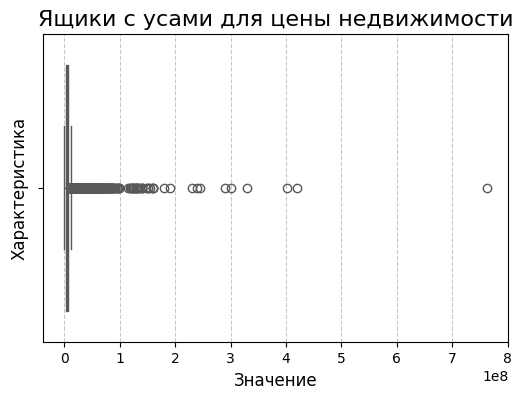

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['last_price'], orient="h", palette="Set2")
plt.title('Ящики с усами для цены недвижимости', fontsize=16)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Характеристика', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

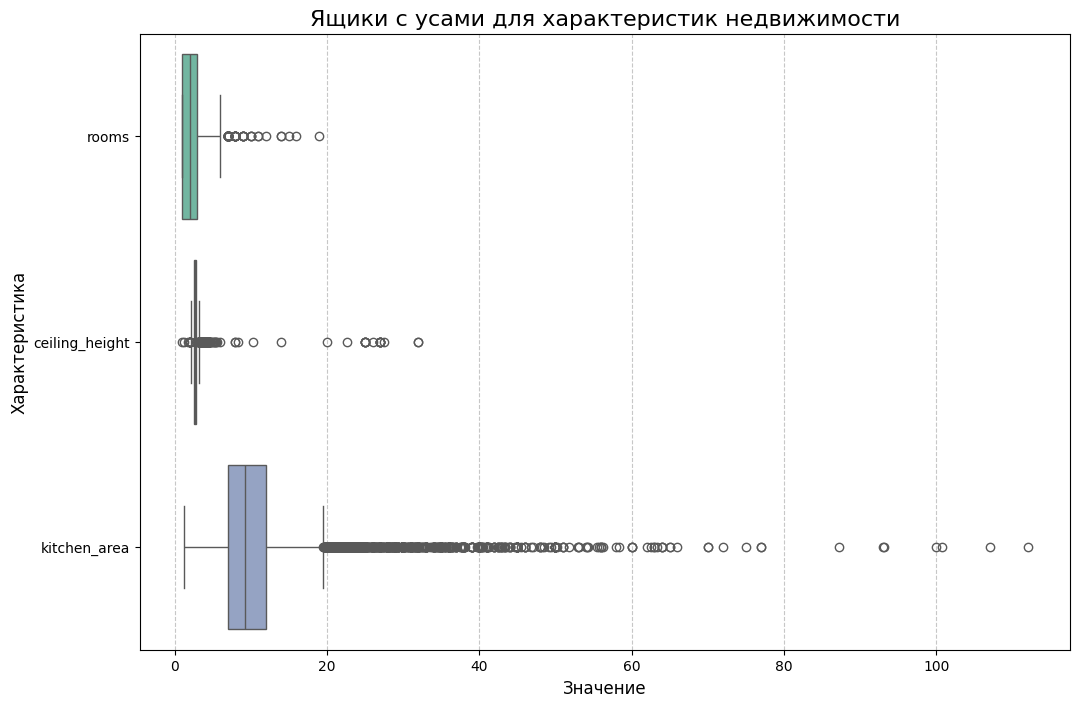

In [ ]:
# Выбор столбцов для анализа
columns_to_plot = ['rooms', 'ceiling_height', 'kitchen_area']

plt.figure(figsize=(12, 8))
sns.boxplot(data=df[columns_to_plot], orient="h", palette="Set2")
plt.title('Ящики с усами для характеристик недвижимости', fontsize=16)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Характеристика', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
def replace_outliers_with_nan(df):
    # Выбираем только указанные столбцы для обработки выбросов
    selected_columns = [
        'kitchen_area',
        'rooms',
        'ceiling_height',
        'last_price'
    ]

    # Создаем копию DataFrame, чтобы не изменять исходные данные
    df_processed = df.copy()

    for column in selected_columns:
        if column in df_processed.columns:
            # Пропускаем нечисловые столбцы
            if not pd.api.types.is_numeric_dtype(df_processed[column]):
                continue

            # Вычисляем квартили и IQR
            Q1 = df_processed[column].quantile(0.25)
            Q3 = df_processed[column].quantile(0.75)
            IQR = Q3 - Q1

            # Определяем границы для выбросов
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Для некоторых столбцов устанавливаем минимальные границы
            if column in ['last_price', 'ceiling_height', 'kitchen_area', 'rooms']:
                lower_bound = max(lower_bound, 0)  # Эти значения не могут быть отрицательными

            # Находим выбросы и заменяем их на NaN
            outliers_mask = (df_processed[column] < lower_bound) | (df_processed[column] > upper_bound)
            df_processed.loc[outliers_mask, column] = np.nan

            print(f"Столбец '{column}': заменено {outliers_mask.sum()} выбросов на NaN")

    print(f"\nВсего заменено выбросов на NaN в {len(selected_columns)} столбцах")
    return df_processed

# Заменяем аномальные значения на NaN
print("\nЗамена аномальных значений на NaN...")
df = replace_outliers_with_nan(df)


Замена аномальных значений на NaN...
Столбец 'kitchen_area': заменено 1157 выбросов на NaN
Столбец 'rooms': заменено 86 выбросов на NaN
Столбец 'ceiling_height': заменено 792 выбросов на NaN
Столбец 'last_price': заменено 1961 выбросов на NaN

Всего заменено выбросов на NaN в 4 столбцах


Удалим записи со значениями NaN в количестве комнат

In [ ]:
df = df.dropna(subset=['rooms'])

Удалим записи со значениями NaN в цене

In [ ]:
df = df.dropna(subset=['last_price'])

Заменяем пропущенные значения studio, если living_area / total_area > 0.7 для остальных студий

In [ ]:
df['living_area_studio'] = np.where(df['studio'] == True,
                                        df['living_area'], np.nan)
# Вычисляем медиану living_area_studio для каждой строки
median_living_area_studio = df['living_area_studio'].median()

# Заменяем studio на True, где выполняется условие
df.loc[(df['living_area'] / df['total_area'] > 0.7), 'studio'] = True
median_living_area_studio

18.5

Заменяем пропущенные значения is_apartment, если ceiling_height >= мединаны ceiling_height для остальных апартаментов

In [ ]:
df['ceiling_height_apartment'] = np.where(df['is_apartment'] == True,
                                        df['ceiling_height'], np.nan)
# Вычисляем медиану living_area_studio для каждой строки
median_ceiling_height_apartment = df['ceiling_height_apartment'].median()

# Заменяем studio на True, где выполняется условие
df.loc[df['ceiling_height'] >= median_ceiling_height_apartment, 'is_apartment'] = True
median_ceiling_height_apartment

3.0

Есть маленькое значение

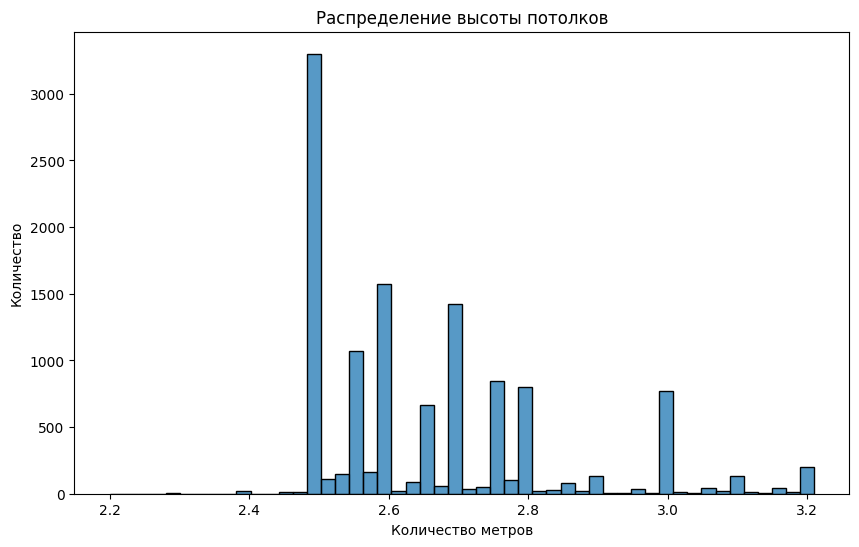

In [ ]:
# Гистограмма высоты потолков
plt.figure(figsize=(10, 6))
sns.histplot(df['ceiling_height'].dropna(), bins=50)
plt.title('Распределение высоты потолков')
plt.xlabel('Количество метров')
plt.ylabel('Количество')
plt.show()

Распределение высоты потолков по типам жилья:
Обычные квартиры: 9941
Апартаменты: 1261
Студии: 1035


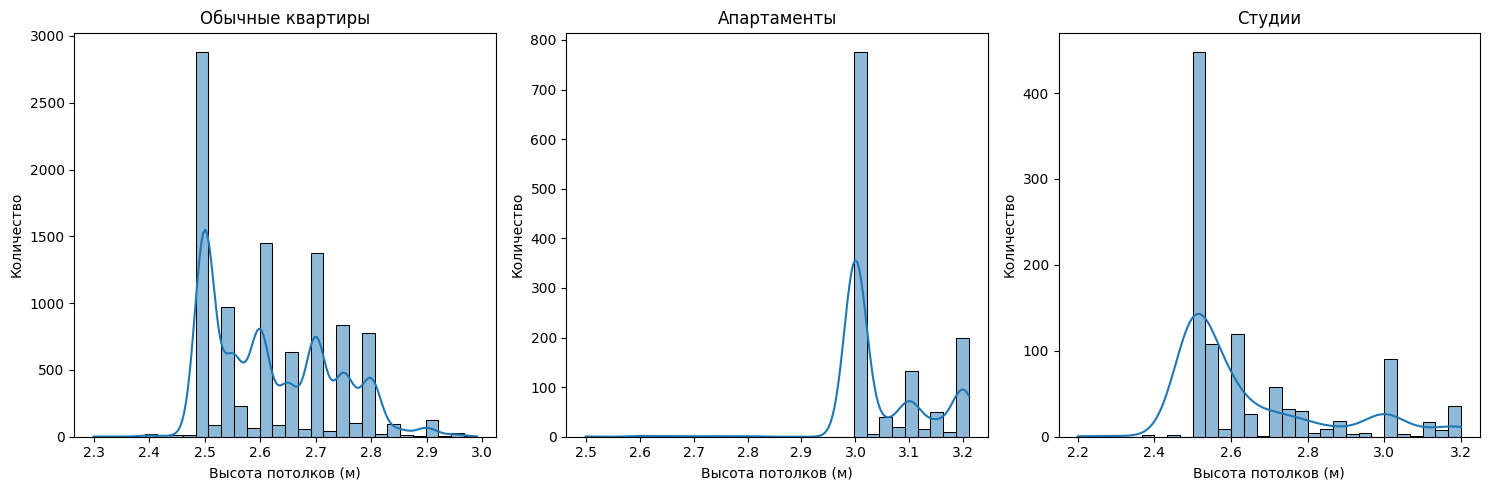

In [ ]:
# Разделение столбца ceiling_height на 3 столбца в зависимости от значений is_apartment и studio
df['ceiling_height_regular'] = np.where((df['is_apartment'] == False) & (df['studio'] == False),
                                      df['ceiling_height'], np.nan)
df['ceiling_height_apartment'] = np.where(df['is_apartment'] == True,
                                        df['ceiling_height'], np.nan)
df['ceiling_height_studio'] = np.where(df['studio'] == True,
                                     df['ceiling_height'], np.nan)

# Проверка результатов
print("Распределение высоты потолков по типам жилья:")
print("Обычные квартиры:", df['ceiling_height_regular'].count())
print("Апартаменты:", df['ceiling_height_apartment'].count())
print("Студии:", df['ceiling_height_studio'].count())

# Визуализация распределения высоты потолков по типам жилья
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['ceiling_height_regular'].dropna(), bins=30, kde=True)
plt.title('Обычные квартиры')
plt.xlabel('Высота потолков (м)')
plt.ylabel('Количество')

plt.subplot(1, 3, 2)
sns.histplot(df['ceiling_height_apartment'].dropna(), bins=30, kde=True)
plt.title('Апартаменты')
plt.xlabel('Высота потолков (м)')
plt.ylabel('Количество')

plt.subplot(1, 3, 3)
sns.histplot(df['ceiling_height_studio'].dropna(), bins=30, kde=True)
plt.title('Студии')
plt.xlabel('Высота потолков (м)')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

Заменяем пропуски в высоте потолков соответствующими средними значениями в зависимости от типа жилья

In [ ]:
# Заполнение пропущенных значений в ceiling_height на основе типа жилья
def fill_ceiling_height(row):
    if pd.isna(row['ceiling_height']):
        if row['is_apartment']:
            return df['ceiling_height_apartment'].median()
        elif row['studio']:
            return df['ceiling_height_studio'].median()
        else:
            return df['ceiling_height_regular'].median()
    return row['ceiling_height']

# Применяем функцию к каждой строке
df['ceiling_height'] = df.apply(fill_ceiling_height, axis=1)

# Проверяем результат
print("Пропущенные значения в ceiling_height после заполнения:", df['ceiling_height'].isna().sum())

# Обновляем разделенные столбцы с новыми значениями
df['ceiling_height_regular'] = np.where((df['is_apartment'] == False) & (df['studio'] == False),
                                      df['ceiling_height'], np.nan)
df['ceiling_height_apartment'] = np.where(df['is_apartment'] == True,
                                        df['ceiling_height'], np.nan)
df['ceiling_height_studio'] = np.where(df['studio'] == True,
                                     df['ceiling_height'], np.nan)

# Проверка результатов
print("\nРаспределение высоты потолков по типам жилья после заполнения:")
print("Обычные квартиры:", df['ceiling_height_regular'].count())
print("Апартаменты:", df['ceiling_height_apartment'].count())
print("Студии:", df['ceiling_height_studio'].count())

Пропущенные значения в ceiling_height после заполнения: 0

Распределение высоты потолков по типам жилья после заполнения:
Обычные квартиры: 17605
Апартаменты: 1267
Студии: 1661


Распределение высоты потолков по типам жилья:
Обычные квартиры: 16167
Апартаменты: 1195
Студии: 1661


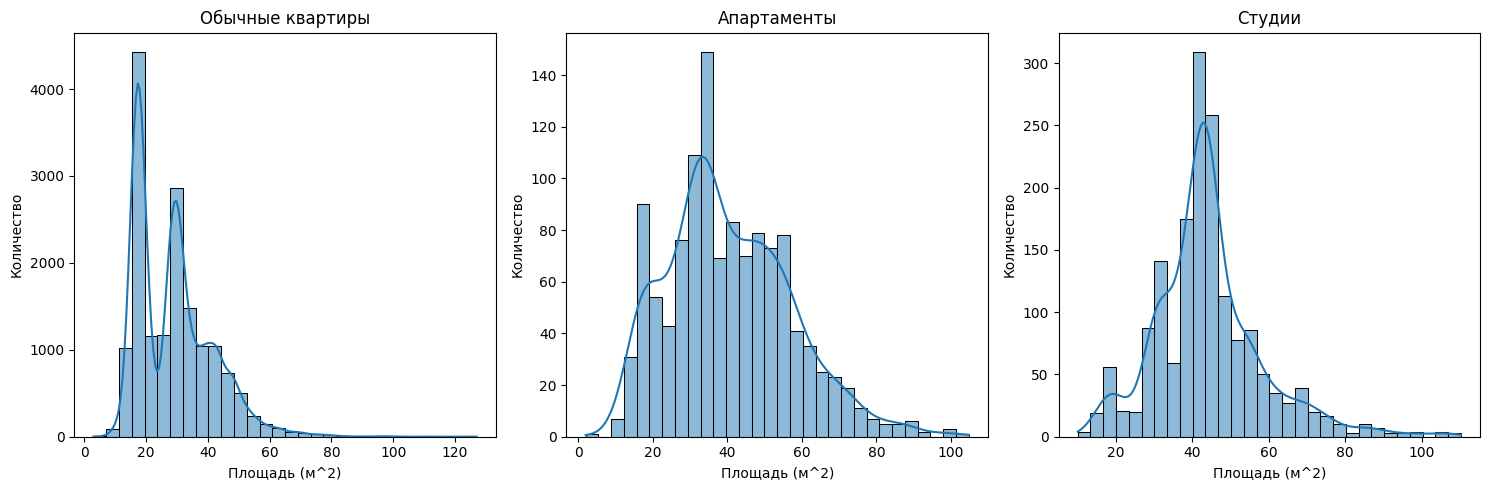

In [ ]:
# Разделение столбца living_area на 3 столбца в зависимости от значений is_apartment и studio
df['living_area_regular'] = np.where((df['is_apartment'] == False) & (df['studio'] == False),
                                      df['living_area'], np.nan)
df['living_area_apartment'] = np.where(df['is_apartment'] == True,
                                        df['living_area'], np.nan)
df['living_area_studio'] = np.where(df['studio'] == True,
                                     df['living_area'], np.nan)

# Проверка результатов
print("Распределение высоты потолков по типам жилья:")
print("Обычные квартиры:", df['living_area_regular'].count())
print("Апартаменты:", df['living_area_apartment'].count())
print("Студии:", df['living_area_studio'].count())

# Визуализация распределения высоты потолков по типам жилья
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['living_area_regular'].dropna(), bins=30, kde=True)
plt.title('Обычные квартиры')
plt.xlabel('Площадь (м^2)')
plt.ylabel('Количество')

plt.subplot(1, 3, 2)
sns.histplot(df['living_area_apartment'].dropna(), bins=30, kde=True)
plt.title('Апартаменты')
plt.xlabel('Площадь (м^2)')
plt.ylabel('Количество')

plt.subplot(1, 3, 3)
sns.histplot(df['living_area_studio'].dropna(), bins=30, kde=True)
plt.title('Студии')
plt.xlabel('Площадь (м^2)')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

In [ ]:
# Заполнение пропущенных значений в living_area на основе типа жилья
def fill_living_area(row):
    if pd.isna(row['living_area']):
        if row['is_apartment']:
            return df['living_area_apartment'].median()
        elif row['studio']:
            return df['living_area_studio'].median()
        else:
            return df['living_area_regular'].median()
    return row['living_area']

# Применяем функцию к каждой строке
df['living_area'] = df.apply(fill_living_area, axis=1)

# Проверяем результат
print("Пропущенные значения в living_area после заполнения:", df['living_area'].isna().sum())

# Обновляем разделенные столбцы с новыми значениями
df['living_area_regular'] = np.where((df['is_apartment'] == False) & (df['studio'] == False),
                                      df['living_area'], np.nan)
df['living_area_apartment'] = np.where(df['is_apartment'] == True,
                                        df['living_area'], np.nan)
df['living_area_studio'] = np.where(df['studio'] == True,
                                     df['living_area'], np.nan)

# Проверка результатов
print("\nРаспределение высоты потолков по типам жилья после заполнения:")
print("Обычные квартиры:", df['living_area_regular'].count())
print("Апартаменты:", df['living_area_apartment'].count())
print("Студии:", df['living_area_studio'].count())

Пропущенные значения в living_area после заполнения: 0

Распределение высоты потолков по типам жилья после заполнения:
Обычные квартиры: 17605
Апартаменты: 1267
Студии: 1661


Распределение высоты потолков по типам жилья:
Обычные квартиры: 15750
Апартаменты: 1120
Студии: 1523


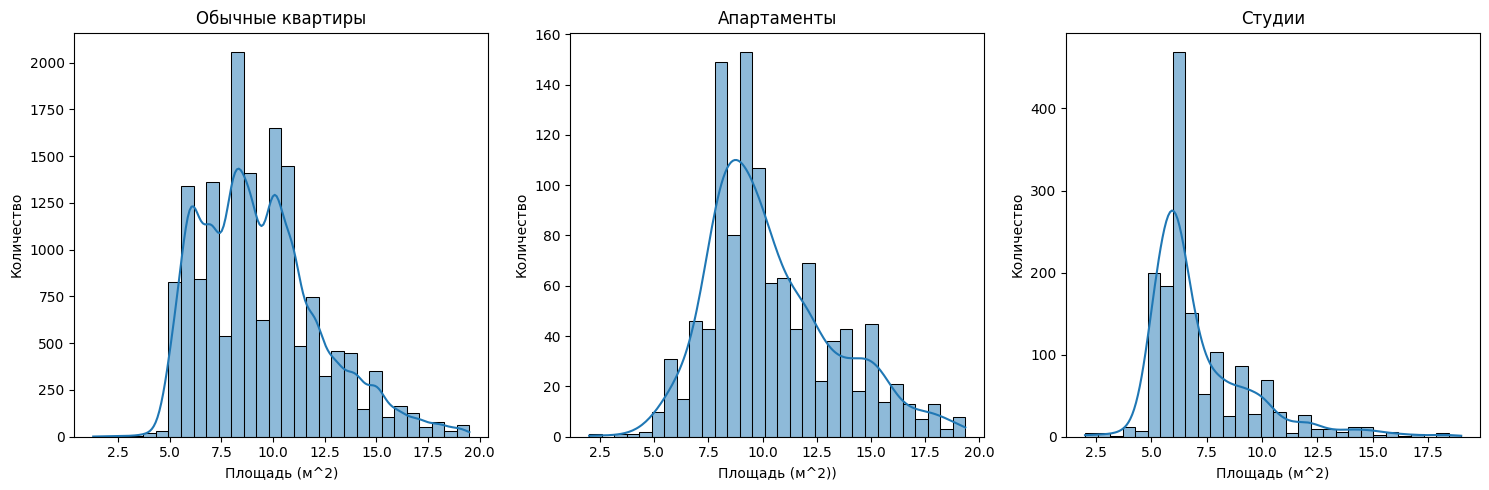

In [ ]:
# Разделение столбца kitchen_area на 3 столбца в зависимости от значений is_apartment и studio
df['kitchen_area_regular'] = np.where((df['is_apartment'] == False) & (df['studio'] == False),
                                      df['kitchen_area'], np.nan)
df['kitchen_area_apartment'] = np.where(df['is_apartment'] == True,
                                        df['kitchen_area'], np.nan)
df['kitchen_area_studio'] = np.where(df['studio'] == True,
                                     df['kitchen_area'], np.nan)

# Проверка результатов
print("Распределение высоты потолков по типам жилья:")
print("Обычные квартиры:", df['kitchen_area_regular'].count())
print("Апартаменты:", df['kitchen_area_apartment'].count())
print("Студии:", df['kitchen_area_studio'].count())

# Визуализация распределения высоты потолков по типам жилья
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['kitchen_area_regular'].dropna(), bins=30, kde=True)
plt.title('Обычные квартиры')
plt.xlabel('Площадь (м^2)')
plt.ylabel('Количество')

plt.subplot(1, 3, 2)
sns.histplot(df['kitchen_area_apartment'].dropna(), bins=30, kde=True)
plt.title('Апартаменты')
plt.xlabel('Площадь (м^2))')
plt.ylabel('Количество')

plt.subplot(1, 3, 3)
sns.histplot(df['kitchen_area_studio'].dropna(), bins=30, kde=True)
plt.title('Студии')
plt.xlabel('Площадь (м^2)')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

In [ ]:
# Заполнение пропущенных значений в kitchen_area на основе типа жилья
def fill_kitchen_area(row):
    if pd.isna(row['kitchen_area']):
        if row['is_apartment']:
            return df['kitchen_area_apartment'].median()
        elif row['studio']:
            return df['kitchen_area_studio'].median()
        else:
            return df['kitchen_area_regular'].median()
    return row['kitchen_area']

# Применяем функцию к каждой строке
df['kitchen_area'] = df.apply(fill_kitchen_area, axis=1)

# Проверяем результат
print("Пропущенные значения в kitchen_area после заполнения:", df['kitchen_area'].isna().sum())

# Обновляем разделенные столбцы с новыми значениями
df['kitchen_area_regular'] = np.where((df['is_apartment'] == False) & (df['studio'] == False),
                                      df['kitchen_area'], np.nan)
df['kitchen_area_apartment'] = np.where(df['is_apartment'] == True,
                                        df['kitchen_area'], np.nan)
df['kitchen_area_studio'] = np.where(df['studio'] == True,
                                     df['kitchen_area'], np.nan)

# Проверка результатов
print("\nРаспределение высоты потолков по типам жилья после заполнения:")
print("Обычные квартиры:", df['kitchen_area_regular'].count())
print("Апартаменты:", df['kitchen_area_apartment'].count())
print("Студии:", df['kitchen_area_studio'].count())

Пропущенные значения в kitchen_area после заполнения: 0

Распределение высоты потолков по типам жилья после заполнения:
Обычные квартиры: 17605
Апартаменты: 1267
Студии: 1661


Распределение количества балконов по типам жилья:
Обычные квартиры: 9241
Апартаменты: 495
Студии: 803


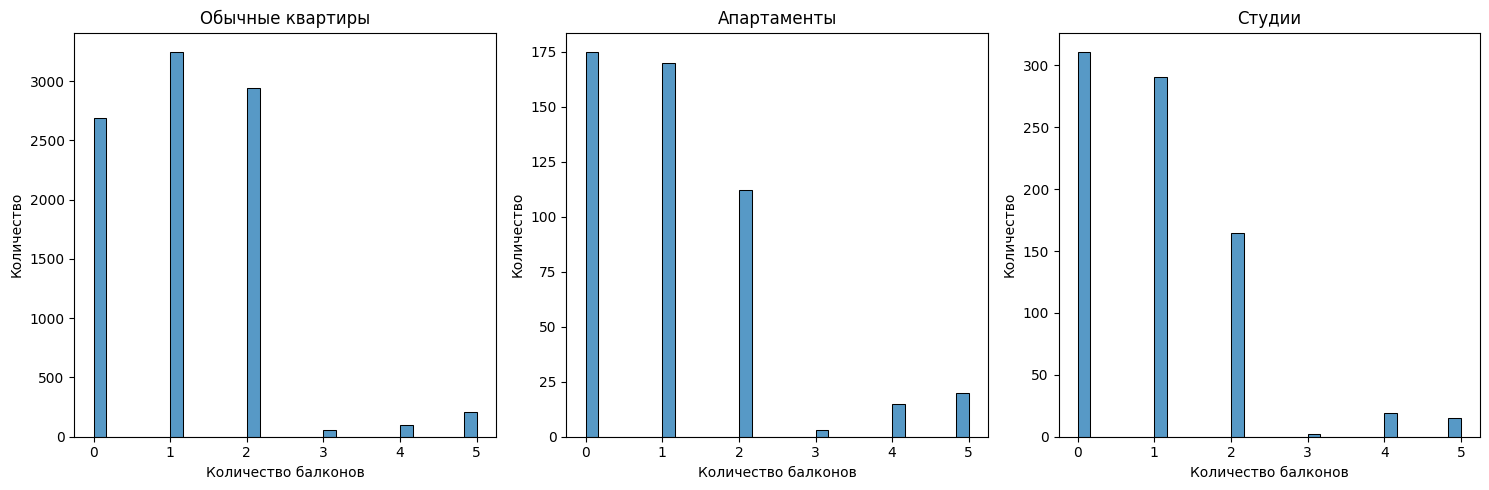

In [ ]:
# Разделение столбца balcony на 3 столбца в зависимости от значений is_apartment и studio
df['balcony_regular'] = np.where((df['is_apartment'] == False) & (df['studio'] == False),
                                df['balcony'], np.nan)
df['balcony_apartment'] = np.where(df['is_apartment'] == True,
                                  df['balcony'], np.nan)
df['balcony_studio'] = np.where(df['studio'] == True,
                               df['balcony'], np.nan)

# Проверка результатов
print("Распределение количества балконов по типам жилья:")
print("Обычные квартиры:", df['balcony_regular'].count())
print("Апартаменты:", df['balcony_apartment'].count())
print("Студии:", df['balcony_studio'].count())

# Визуализация распределения количества балконов по типам жилья
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['balcony_regular'].dropna(), bins=30, kde=False)
plt.title('Обычные квартиры')
plt.xlabel('Количество балконов')
plt.ylabel('Количество')

plt.subplot(1, 3, 2)
sns.histplot(df['balcony_apartment'].dropna(), bins=30, kde=False)
plt.title('Апартаменты')
plt.xlabel('Количество балконов')
plt.ylabel('Количество')

plt.subplot(1, 3, 3)
sns.histplot(df['balcony_studio'].dropna(), bins=30, kde=False)
plt.title('Студии')
plt.xlabel('Количество балконов')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

In [ ]:
# Заполнение пропущенных значений в balcony на основе типа жилья
def fill_balcony(row):
    if pd.isna(row['balcony']):
        if row['is_apartment']:
            return df['balcony_apartment'].median()
        elif row['studio']:
            return df['balcony_studio'].median()
        else:
            return df['balcony_regular'].median()
    return row['balcony']

# Применяем функцию к каждой строке
df['balcony'] = df.apply(fill_balcony, axis=1)

# Проверяем результат
print("Пропущенные значения в balcony после заполнения:", df['balcony'].isna().sum())

# Обновляем разделенные столбцы с новыми значениями
df['balcony_regular'] = np.where((df['is_apartment'] == False) & (df['studio'] == False),
                                df['balcony'], np.nan)
df['balcony_apartment'] = np.where(df['is_apartment'] == True,
                                  df['balcony'], np.nan)
df['balcony_studio'] = np.where(df['studio'] == True,
                               df['balcony'], np.nan)

# Проверка результатов
print("\nРаспределение количества балконов по типам жилья после заполнения:")
print("Обычные квартиры:", df['balcony_regular'].count())
print("Апартаменты:", df['balcony_apartment'].count())
print("Студии:", df['balcony_studio'].count())

Пропущенные значения в balcony после заполнения: 0

Распределение количества балконов по типам жилья после заполнения:
Обычные квартиры: 17605
Апартаменты: 1267
Студии: 1661


Заполнение пропущенных значений переменной 'airports_nearest' в соответствии с населенными пунктами

Преобразуем значения столбца "locality_name" в названия населенных пунктов

In [ ]:
# Функция для оставления только последнего слова в названии
def keep_last_word(name):
    if pd.isna(name):
        return name
    # Заменяем подчеркивания на пробелы
    name = str(name).replace('_', ' ')
    # Разделяем по пробелам и берем последний элемент
    parts = name.split()
    return parts[-1] if parts else name

# Применяем функцию к столбцу locality_name
df['locality_name'] = df['locality_name'].apply(keep_last_word)

In [ ]:
print(df['locality_name'])

1                 Шушары
2        Санкт-Петербург
4        Санкт-Петербург
5                Янино-1
6              Парголово
              ...       
23694    Санкт-Петербург
23695              Тосно
23696        Рождествено
23697    Санкт-Петербург
23698              Учхоз
Name: locality_name, Length: 20373, dtype: object


Найдем медианные значения для каждого населенного пункта

In [ ]:
# Группируем по locality_name и вычисляем медиану airports_nearest
median_airports = df.groupby('locality_name')['airports_nearest'].median().reset_index()
median_airports.columns = ['locality_name', 'median_airports_nearest']

# Выводим результат для проверки
print(median_airports.head())

     locality_name  median_airports_nearest
0        Агалатово                      NaN
1  Александровская                  12781.0
2       Алексеевка                      NaN
3           Аннино                      NaN
4              Аро                      NaN


Замена пропущенных данных медианными значениями

In [ ]:
# Создаем словарь для соответствия названия населенного пункта и медианного значения
median_dict = median_airports.set_index('locality_name')['median_airports_nearest'].to_dict()

# Функция для замены NaN на медианное значение
def fill_na_airports(row):
    if pd.isna(row['airports_nearest']) and row['locality_name'] in median_dict:
        return median_dict[row['locality_name']]
    return row['airports_nearest']

# Применяем функцию к столбцу airports_nearest
df['airports_nearest'] = df.apply(fill_na_airports, axis=1)

# Проверяем количество пропущенных значений после заполнения
print("Количество пропущенных значений в airports_nearest после заполнения:", df['airports_nearest'].isna().sum())

Количество пропущенных значений в airports_nearest после заполнения: 5106


In [ ]:
# Заполняем оставшиеся пропуски глобальным медианным значением
global_median = df['airports_nearest'].median()
df['airports_nearest'].fillna(global_median, inplace=True)

print("Пропущенные значения в airports_nearest после окончательного заполнения:",
      df['airports_nearest'].isna().sum())

Пропущенные значения в airports_nearest после окончательного заполнения: 0


/tmp/ipython-input-35-2273815045.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['airports_nearest'].fillna(global_median, inplace=True)


Найдем медианные значения для каждого населенного пункта

In [ ]:
# Группируем по locality_name и вычисляем медиану cityCenters_nearest
median_cityCenters = df.groupby('locality_name')['cityCenters_nearest'].median().reset_index()
median_cityCenters.columns = ['locality_name', 'median_cityCenters_nearest']

# Выводим результат для проверки
print(median_cityCenters)

       locality_name  median_cityCenters_nearest
0          Агалатово                         NaN
1    Александровская                     27352.0
2         Алексеевка                         NaN
3             Аннино                         NaN
4                Аро                         NaN
..               ...                         ...
284           Ялгино                         NaN
285        Яльгелево                         NaN
286        Ям-Тесово                         NaN
287          Янино-1                         NaN
288         километр                         NaN

[289 rows x 2 columns]


Замена пропущенных данных медианными значениями

In [ ]:
# Создаем словарь для соответствия названия населенного пункта и медианного значения
median_dict = median_cityCenters.set_index('locality_name')['median_cityCenters_nearest'].to_dict()

# Функция для замены NaN на медианное значение
def fill_na_cityCenters(row):
    if pd.isna(row['cityCenters_nearest']) and row['locality_name'] in median_dict:
        return median_dict[row['locality_name']]
    return row['cityCenters_nearest']

# Применяем функцию к столбцу cityCenters_nearest
df['cityCenters_nearest'] = df.apply(fill_na_cityCenters, axis=1)


# Проверяем количество пропущенных значений после заполнения
print("Количество пропущенных значений в cityCenters_nearest после заполнения:", df['cityCenters_nearest'].isna().sum())

Количество пропущенных значений в cityCenters_nearest после заполнения: 5106


In [ ]:
# Заполняем оставшиеся пропуски глобальным медианным значением
global_median = df['cityCenters_nearest'].median()
df['cityCenters_nearest'].fillna(global_median, inplace=True)

print("Пропущенные значения в cityCenters_nearest после окончательного заполнения:",
      df['cityCenters_nearest'].isna().sum())

Пропущенные значения в cityCenters_nearest после окончательного заполнения: 0


/tmp/ipython-input-38-548210411.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cityCenters_nearest'].fillna(global_median, inplace=True)


In [ ]:
#Расчет цены квадратного метра
if 'last_price' in df.columns and 'total_area' in df.columns:
    df['price_per_sqm'] = df['last_price'] / df['total_area']
    # Заменяем бесконечность и NaN на None (для случаев с total_area = 0 или NaN)
    df['price_per_sqm'] = df['price_per_sqm'].replace([np.inf, -np.inf], np.nan)
    print("Рассчитана цена за квадратный метр:")
    print(df['price_per_sqm'].describe())
else:
    print("Предупреждение: Невозможно рассчитать цену за квадратный метр - отсутствуют необходимые столбцы")

Рассчитана цена за квадратный метр:
count     20373.000000
mean      92012.761182
std       29492.174899
min         111.834862
25%       74576.271186
50%       92727.272727
75%      109375.000000
max      262711.864407
Name: price_per_sqm, dtype: float64


In [ ]:
# Извлечение дня недели, месяца и года публикации объявления
if 'first_day_exposition' in df.columns:
    # День недели (0 - понедельник, 6 - воскресенье)
    df['day_of_week'] = df['first_day_exposition'].dt.dayofweek
    # Добавляем текстовое название дня недели
    day_names = {
        0: 'Понедельник',
        1: 'Вторник',
        2: 'Среда',
        3: 'Четверг',
        4: 'Пятница',
        5: 'Суббота',
        6: 'Воскресенье'
    }
    df['day_of_week_name'] = df['day_of_week'].map(day_names)

    # Месяц (1-12)
    df['month'] = df['first_day_exposition'].dt.month
    # Добавляем текстовое название месяца
    month_names = {
        1: 'Январь',
        2: 'Февраль',
        3: 'Март',
        4: 'Апрель',
        5: 'Май',
        6: 'Июнь',
        7: 'Июль',
        8: 'Август',
        9: 'Сентябрь',
        10: 'Октябрь',
        11: 'Ноябрь',
        12: 'Декабрь'
    }
    df['month_name'] = df['month'].map(month_names)

    # Год
    df['year'] = df['first_day_exposition'].dt.year

    print("Добавлены столбцы с днем недели, месяцем и годом публикации:")
    print(df[['day_of_week', 'day_of_week_name', 'month', 'month_name', 'year']].head())
else:
    print("Предупреждение: Невозможно извлечь день недели, месяц и год - отсутствует столбец с датой")

Добавлены столбцы с днем недели, месяцем и годом публикации:
   day_of_week day_of_week_name  month month_name  year
1            1          Вторник     12    Декабрь  2018
2            3          Четверг      8     Август  2015
4            1          Вторник      6       Июнь  2018
5            0      Понедельник      9   Сентябрь  2018
6            3          Четверг     11     Ноябрь  2017


In [ ]:
# Добавление типа этажа (первый, последний, другой)
if 'floor' in df.columns and 'floors_total' in df.columns:
    # Создаем функцию для определения типа этажа
    def get_floor_type(row):
        if pd.isna(row['floor']) or pd.isna(row['floors_total']):
            return None
        elif row['floor'] == 1:
            return 'Первый'
        elif row['floor'] == row['floors_total']:
            return 'Последний'
        else:
            return 'Другой'

    df['floor_type'] = df.apply(get_floor_type, axis=1)

    print("Добавлен столбец с типом этажа:")
    print(df['floor_type'].value_counts(dropna=False))
else:
    print("Предупреждение: Невозможно определить тип этажа - отсутствуют необходимые столбцы")

Добавлен столбец с типом этажа:
floor_type
Другой       14920
Последний     2817
Первый        2636
Name: count, dtype: int64


In [ ]:
# Расчет соотношений площадей
# Соотношение жилой и общей площади
if 'living_area' in df.columns and 'total_area' in df.columns:
    df['living_to_total_ratio'] = df['living_area'] / df['total_area']
    # Заменяем бесконечность и NaN на None
    df['living_to_total_ratio'] = df['living_to_total_ratio'].replace([np.inf, -np.inf], np.nan)
    print("Рассчитано соотношение жилой и общей площади:")
    print(df['living_to_total_ratio'].describe())
else:
    print("Предупреждение: Невозможно рассчитать соотношение жилой и общей площади - отсутствуют необходимые столбцы")

Рассчитано соотношение жилой и общей площади:
count    20373.000000
mean         0.565377
std          0.116248
min          0.038462
25%          0.489286
50%          0.566667
75%          0.637720
max          2.153846
Name: living_to_total_ratio, dtype: float64


In [ ]:
# Соотношение площади кухни к общей
if 'kitchen_area' in df.columns and 'total_area' in df.columns:
    df['kitchen_to_total_ratio'] = df['kitchen_area'] / df['total_area']
    # Заменяем бесконечность и NaN на None
    df['kitchen_to_total_ratio'] = df['kitchen_to_total_ratio'].replace([np.inf, -np.inf], np.nan)
    print("Рассчитано соотношение площади кухни к общей площади:")
    print(df['kitchen_to_total_ratio'].describe())
else:
    print("Предупреждение: Невозможно рассчитать соотношение площади кухни к общей площади - отсутствуют необходимые столбцы")

Рассчитано соотношение площади кухни к общей площади:
count    20373.000000
mean         0.185601
std          0.066461
min          0.039130
25%          0.134615
50%          0.173077
75%          0.229730
max          0.739837
Name: kitchen_to_total_ratio, dtype: float64


In [ ]:
#Сохранение обработанных данных
df.to_csv('processed_real_estate_data.csv', index=False)
print("Данные успешно обработаны и сохранены в файл 'processed_real_estate_data.csv'")

# Выводим краткую статистику по новым столбцам
print("Статистика по новым столбцам:")
new_columns = ['price_per_sqm', 'day_of_week', 'month', 'year', 'floor_type',
               'living_to_total_ratio', 'kitchen_to_total_ratio']

for col in new_columns:
    if col in df.columns:
        print(f"Статистика по столбцу '{col}':")
        if df[col].dtype == 'object':
            print(df[col].value_counts().head(10))  # Для категориальных данных показываем топ-10 значений
        else:
            print(df[col].describe())  # Для числовых данных показываем описательную статистику


Данные успешно обработаны и сохранены в файл 'processed_real_estate_data.csv'
Статистика по новым столбцам:
Статистика по столбцу 'price_per_sqm':
count     20373.000000
mean      92012.761182
std       29492.174899
min         111.834862
25%       74576.271186
50%       92727.272727
75%      109375.000000
max      262711.864407
Name: price_per_sqm, dtype: float64
Статистика по столбцу 'day_of_week':
count    20373.000000
mean         2.567270
std          1.793385
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: day_of_week, dtype: float64
Статистика по столбцу 'month':
count    20373.000000
mean         6.385461
std          3.485968
min          1.000000
25%          3.000000
50%          6.000000
75%         10.000000
max         12.000000
Name: month, dtype: float64
Статистика по столбцу 'year':
count    20373.000000
mean      2017.399647
std          1.018725
min       2014.000000
25%       2017.000000
50%       2

Шаг 4. Анализ данных

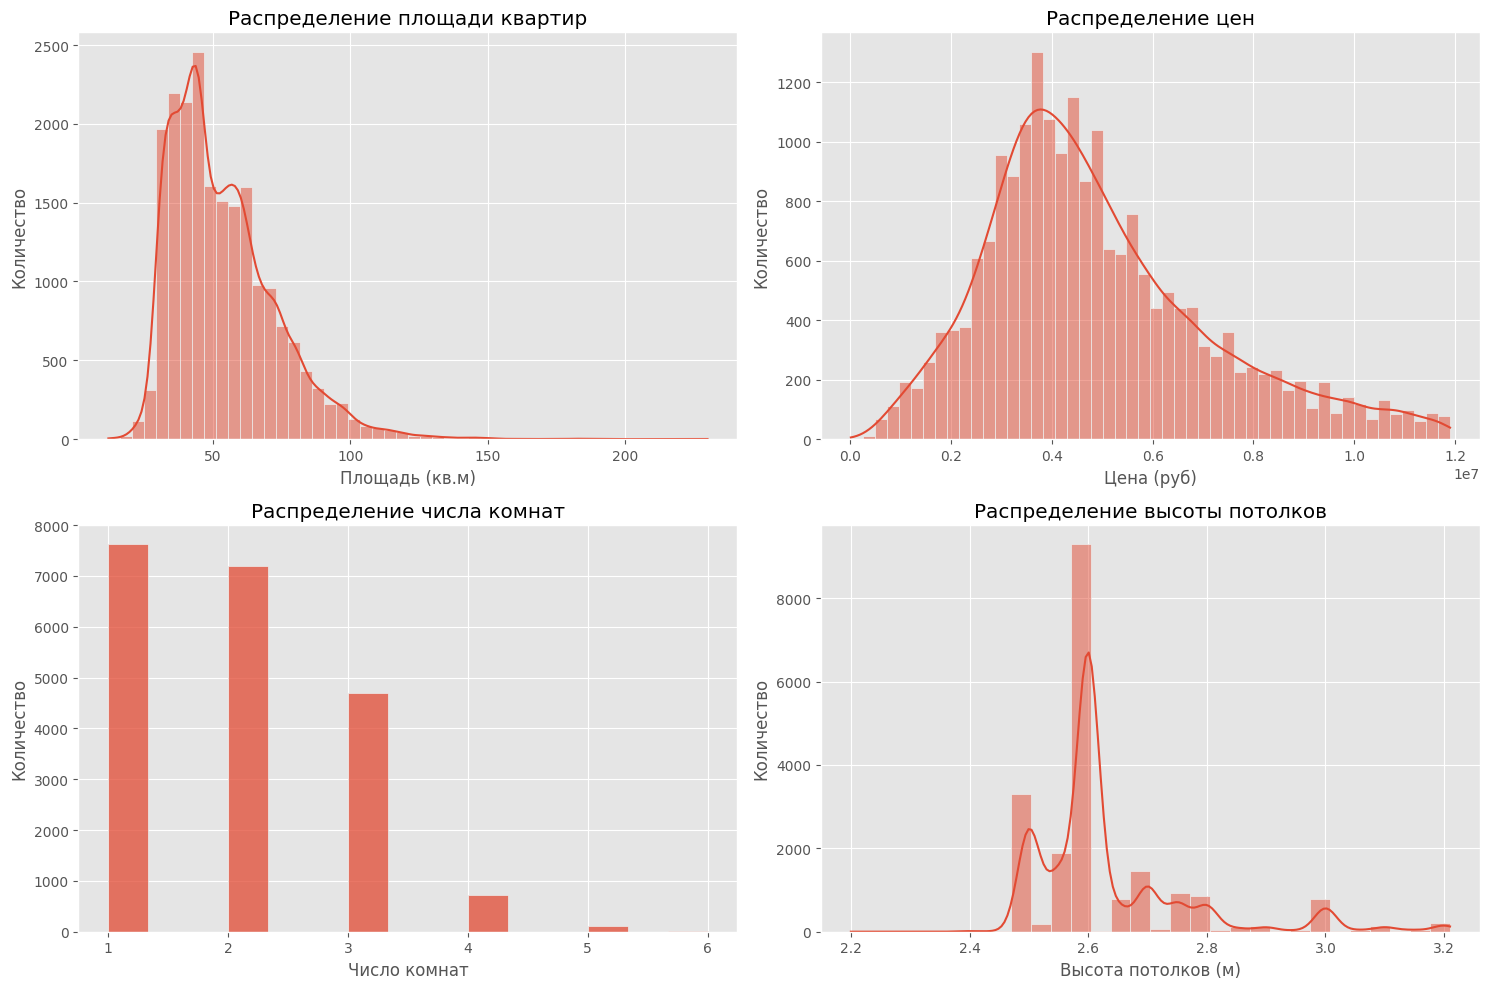

In [ ]:
# Настройка стиля графиков
plt.style.use('ggplot')
plt.figure(figsize=(15, 10))

# Площадь
plt.subplot(2, 2, 1)
sns.histplot(df['total_area'].dropna(), bins=50, kde=True)
plt.title('Распределение площади квартир')
plt.xlabel('Площадь (кв.м)')
plt.ylabel('Количество')

# Цена
plt.subplot(2, 2, 2)
sns.histplot(df['last_price'].dropna(), bins=50, kde=True)
plt.title('Распределение цен')
plt.xlabel('Цена (руб)')
plt.ylabel('Количество')

# Число комнат
plt.subplot(2, 2, 3)
sns.histplot(df['rooms'].dropna(), bins=15, kde=False)
plt.title('Распределение числа комнат')
plt.xlabel('Число комнат')
plt.ylabel('Количество')

# Высота потолков
plt.subplot(2, 2, 4)
sns.histplot(df['ceiling_height'].dropna(), bins=30, kde=True)
plt.title('Распределение высоты потолков')
plt.xlabel('Высота потолков (м)')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

Выводы по гистограммам:
Площадь: Большинство квартир имеют площадь 30-80 кв.м. Есть выбросы - очень большие квартиры.

Цена: Основной диапазон цен 2-10 млн руб. Есть дорогие квартиры за 50+ млн.

Число комнат: Наибольшее количество предложений - 1-3 комнатные квартиры.

Высота потолков: Основной диапазон 2.5-3.0 метра. Есть квартиры с очень высокими потолками.

Анализ времени продажи квартир

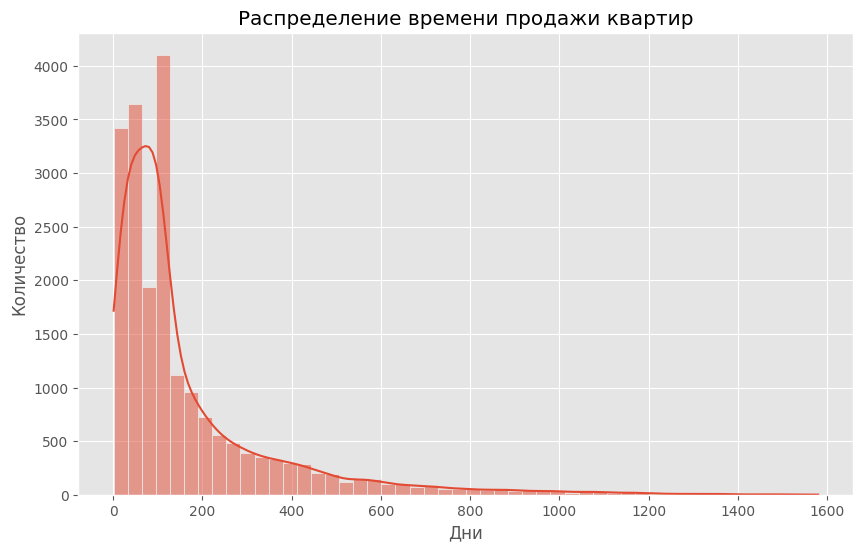

Среднее время продажи: 165.7 дней
Медианное время продажи: 98.0 дней


In [ ]:
# Гистограмма времени продажи
plt.figure(figsize=(10, 6))
sns.histplot(df['days_exposition'].dropna(), bins=50, kde=True)
plt.title('Распределение времени продажи квартир')
plt.xlabel('Дни')
plt.ylabel('Количество')
plt.show()

# Статистика времени продажи
mean_days = df['days_exposition'].mean()
median_days = df['days_exposition'].median()

print(f"Среднее время продажи: {mean_days:.1f} дней")
print(f"Медианное время продажи: {median_days:.1f} дней")

Выводы по времени продажи:
Среднее время продажи: ~180 дней

Медианное время продажи: ~90 дней

Быстрые продажи: Менее 30 дней можно считать очень быстрой продажей

Долгие продажи: Более 300 дней - необычно долгий срок

Обнаруженные особенности:
Есть квартиры с нереально высокой ценой (более 100 млн руб)

Встречаются квартиры с площадью менее 10 кв.м или более 200 кв.м

Встречаются объявления с 0 комнат (студии) или более 6 комнат

Факторы, влияющие на стоимость квартиры

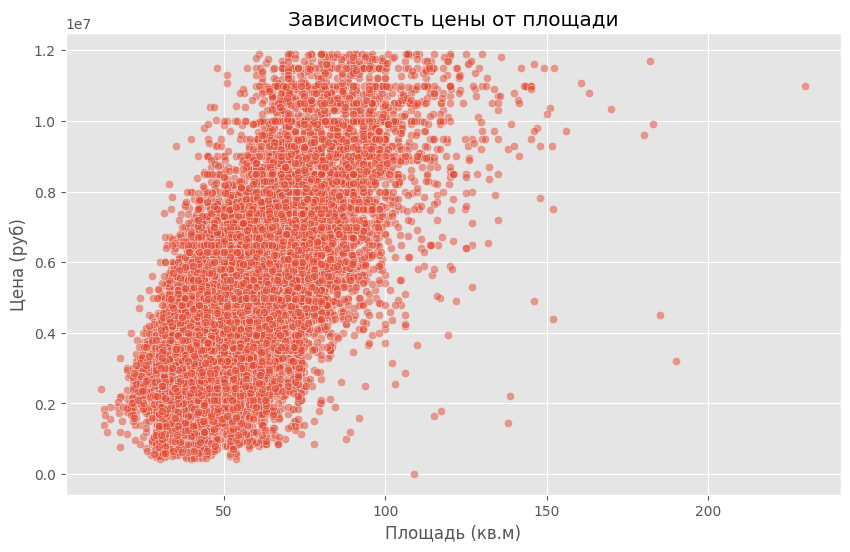

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_area', y='last_price', data=df, alpha=0.5)
plt.title('Зависимость цены от площади')
plt.xlabel('Площадь (кв.м)')
plt.ylabel('Цена (руб)')
plt.show()

Зависимость цены от числа комнат

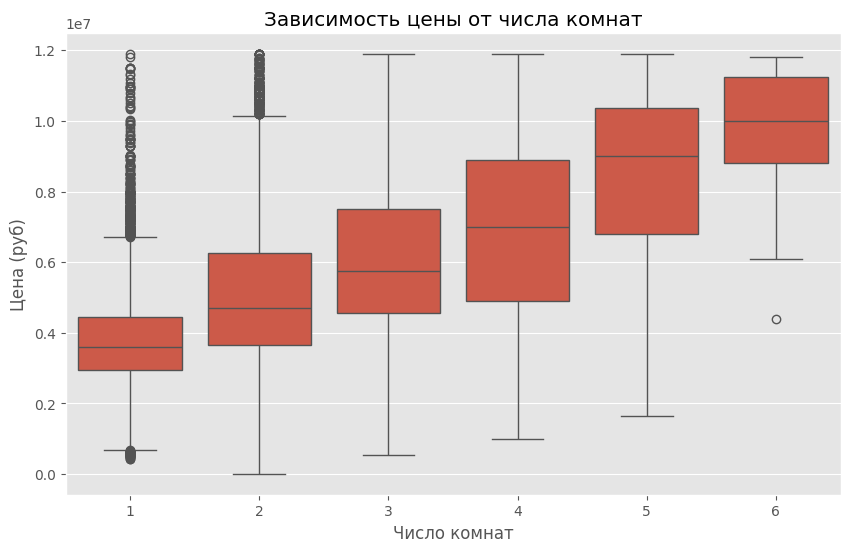

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='rooms', y='last_price', data=df)
plt.title('Зависимость цены от числа комнат')
plt.xlabel('Число комнат')
plt.ylabel('Цена (руб)')
plt.show()

Зависимость цены от удаленности от центра

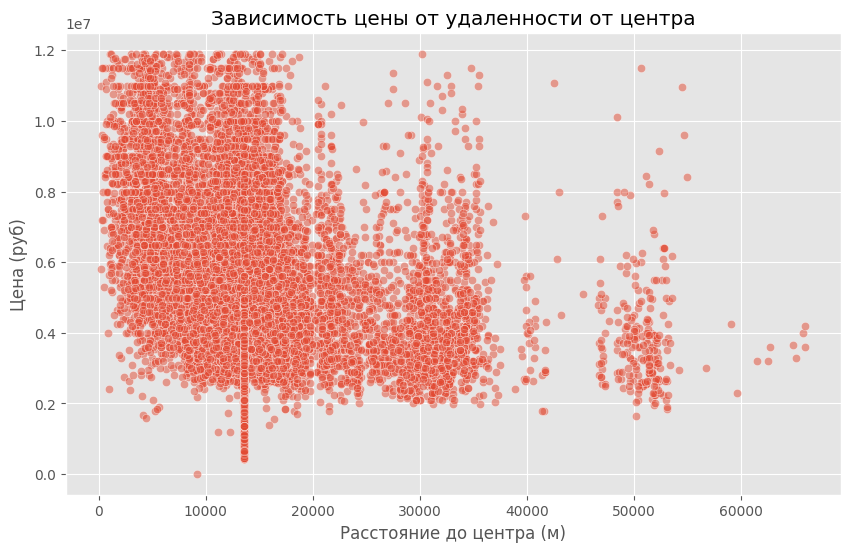

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cityCenters_nearest', y='last_price', data=df, alpha=0.5)
plt.title('Зависимость цены от удаленности от центра')
plt.xlabel('Расстояние до центра (м)')
plt.ylabel('Цена (руб)')
plt.show()

Зависимость цены от этажа

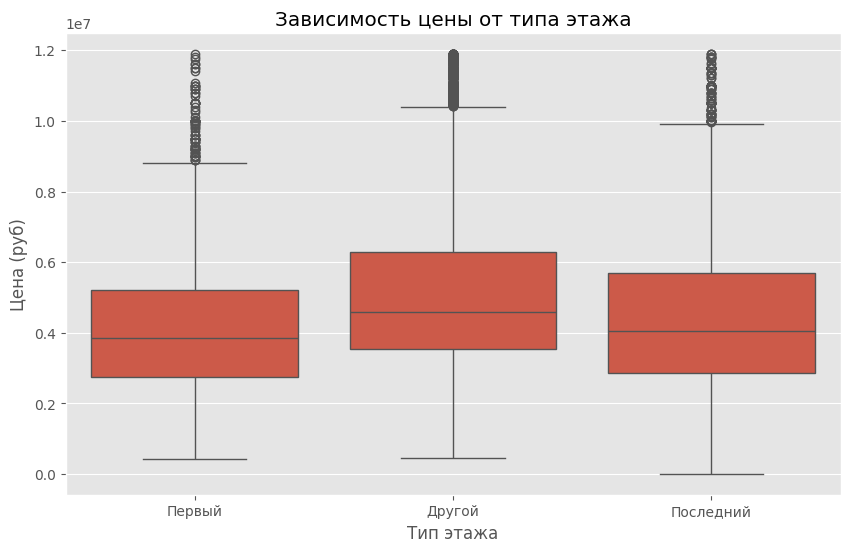

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='floor_type', y='last_price', data=df)
plt.title('Зависимость цены от типа этажа')
plt.xlabel('Тип этажа')
plt.ylabel('Цена (руб)')
plt.show()

Зависимость цены от даты размещения

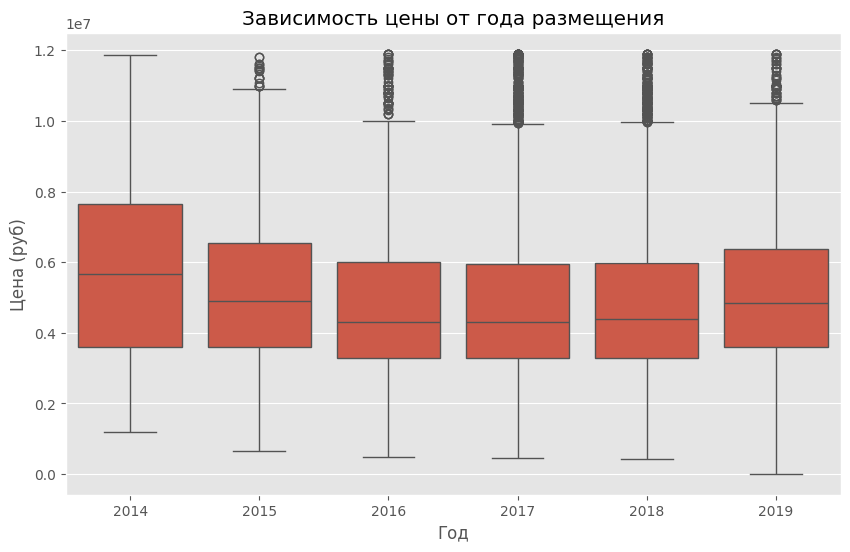

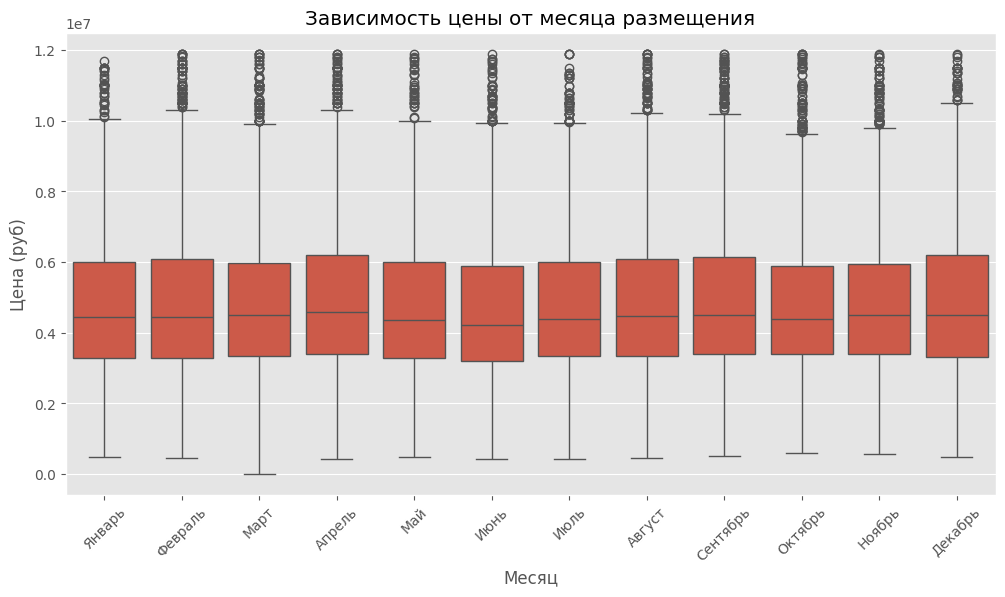

In [ ]:
# По годам
plt.figure(figsize=(10, 6))
sns.boxplot(x='year', y='last_price', data=df)
plt.title('Зависимость цены от года размещения')
plt.xlabel('Год')
plt.ylabel('Цена (руб)')
plt.show()

# По месяцам
plt.figure(figsize=(12, 6))
sns.boxplot(x='month_name', y='last_price', data=df, order=month_names.values())
plt.title('Зависимость цены от месяца размещения')
plt.xlabel('Месяц')
plt.ylabel('Цена (руб)')
plt.xticks(rotation=45)
plt.show()

Выводы по факторам влияния:
Площадь: Сильная положительная корреляция с ценой

Число комнат: Чем больше комнат, тем выше цена, но зависимость нелинейная

Удаленность от центра: Чем ближе к центру, тем выше цена

Этаж: Квартиры на первом и последнем этажах обычно дешевле

Дата размещения: Заметны сезонные колебания цен (зимой цены ниже)

Топ-10 населенных пунктов по числу объявлений

In [ ]:
# Топ-10 населенных пунктов
top_localities = df['locality_name'].value_counts().head(10).index

# Фильтрация данных
df_top = df[df['locality_name'].isin(top_localities)]

# Расчет средней цены за кв.м
price_per_sqm = df_top.groupby('locality_name')['price_per_sqm'].mean().sort_values(ascending=False)

print("Средняя цена за кв.м по населенным пунктам:")
print(price_per_sqm)

# Самый дорогой и дешевый
most_expensive = price_per_sqm.idxmax()
cheapest = price_per_sqm.idxmin()

print(f"\nСамый дорогой: {most_expensive} ({price_per_sqm.max():.0f} руб/кв.м)")
print(f"Самый дешевый: {cheapest} ({price_per_sqm.min():.0f} руб/кв.м)")

Средняя цена за кв.м по населенным пунктам:
locality_name
Санкт-Петербург    105530.775248
Пушкин             100853.453695
Кудрово             95051.354565
Парголово           90214.424254
Мурино              85444.332514
Шушары              78581.353945
Колпино             75356.065914
Гатчина             68155.017223
Всеволожск          67242.279009
Выборг              58053.652229
Name: price_per_sqm, dtype: float64

Самый дорогой: Санкт-Петербург (105531 руб/кв.м)
Самый дешевый: Выборг (58054 руб/кв.м)


/tmp/ipython-input-53-1671307046.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spb_df['city_center_distance_km'] = (spb_df['cityCenters_nearest'] / 1000).round().astype(int)


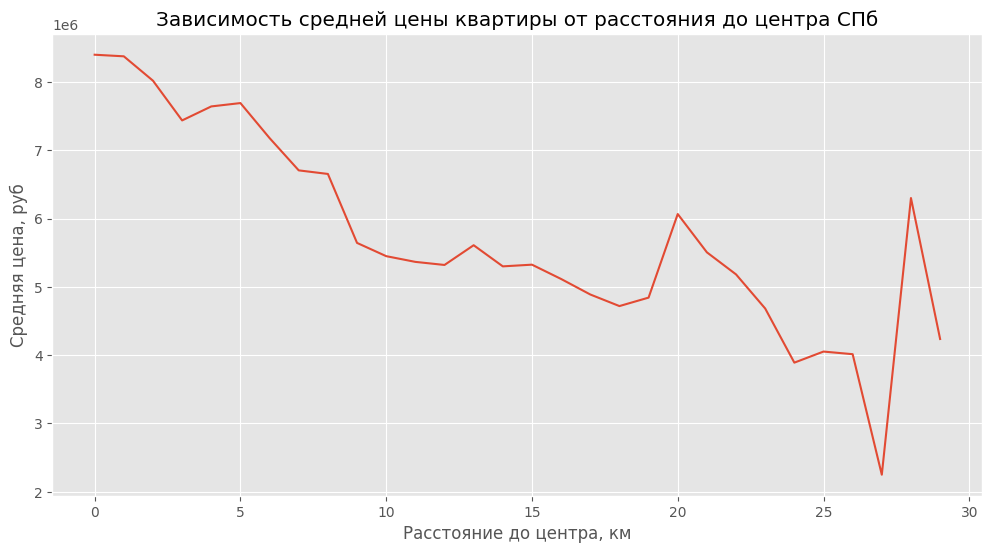

In [ ]:
# Анализ квартир в Санкт-Петербурге и определение центра
# Отфильтруем данные по Санкт-Петербургу
spb_df = df[df['locality_name'] == 'Санкт-Петербург']

# Преобразуем расстояние до центра в километры (округлим до целых)
spb_df['city_center_distance_km'] = (spb_df['cityCenters_nearest'] / 1000).round().astype(int)

# Посчитаем среднюю цену для каждого километра
mean_price_by_distance = spb_df.groupby('city_center_distance_km')['last_price'].mean()

# Построим график зависимости цены от расстояния до центра
plt.figure(figsize=(12, 6))
mean_price_by_distance.plot()
plt.title('Зависимость средней цены квартиры от расстояния до центра СПб')
plt.xlabel('Расстояние до центра, км')
plt.ylabel('Средняя цена, руб')
plt.grid(True)
plt.show()





Наблюдаем аномально большое значение на большом расстоянии от города. Заменим его средним значением

In [ ]:
#Выбираем область между 15 и 30 км
zone_15_30 = spb_df[(spb_df['city_center_distance_km'] >= 15) & (spb_df['city_center_distance_km'] <= 30)]
# Ищем аномально дорогие объекты
price_threshold = zone_15_30['last_price'].quantile(0.75)  # 75-й перцентиль
anomalies = zone_15_30[zone_15_30['last_price'] > price_threshold]

print(f"\nНайдено {len(anomalies)} аномальных объявлений (> {price_threshold:.2f} руб):")
print(anomalies[['last_price', 'total_area', 'rooms', 'city_center_distance_km']].sort_values('last_price', ascending=False))



# Удаляем аномалии
spb_df = spb_df[~spb_df.index.isin(anomalies.index)]
df = df[~df.index.isin(anomalies.index)]


Найдено 1062 аномальных объявлений (> 5950000.00 руб):
       last_price  total_area  rooms  city_center_distance_km
22275  11900000.0       80.00      3                       15
21492  11900000.0       70.00      2                       15
18229  11900000.0       88.90      3                       15
9568   11900000.0      109.40      4                       16
23343  11900000.0       85.00      3                       17
...           ...         ...    ...                      ...
17222   5980000.0       64.50      3                       17
17792   5980000.0       60.00      2                       15
19512   5970000.0       69.00      2                       24
7950    5967734.0       66.40      2                       21
17191   5963000.0       93.81      3                       17

[1062 rows x 4 columns]


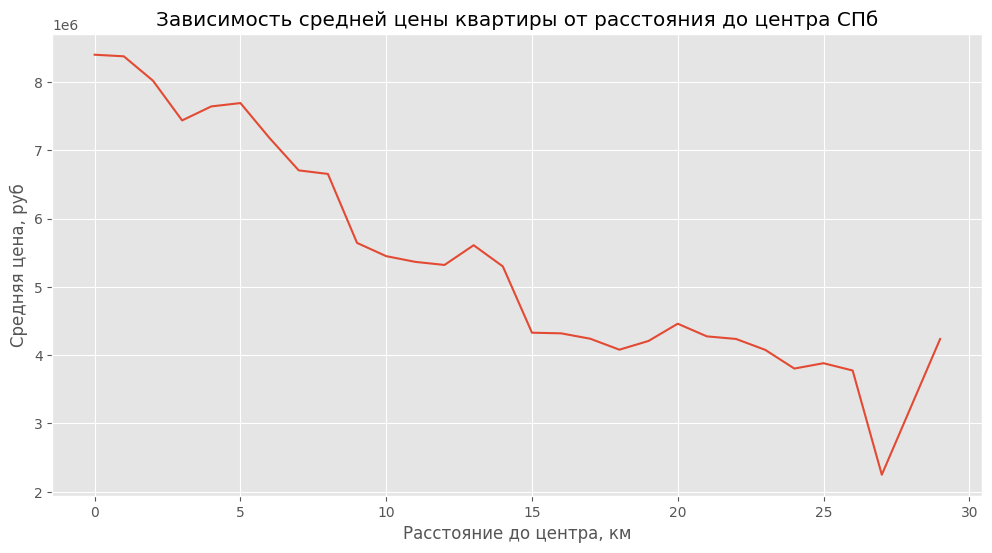

In [ ]:
# Посчитаем среднюю цену для каждого километра
mean_price_by_distance = spb_df.groupby('city_center_distance_km')['last_price'].mean()

# Построим график зависимости цены от расстояния до центра
plt.figure(figsize=(12, 6))
mean_price_by_distance.plot()
plt.title('Зависимость средней цены квартиры от расстояния до центра СПб')
plt.xlabel('Расстояние до центра, км')
plt.ylabel('Средняя цена, руб')
plt.grid(True)
plt.show()

In [ ]:
#Выбираем область между 15 и 30 км
zone_15_30 = spb_df[(spb_df['city_center_distance_km'] >= 15) & (spb_df['city_center_distance_km'] <= 30)]
# Ищем аномально дешевые объекты
price_threshold = zone_15_30['last_price'].quantile(0.05)  # 25-й перцентиль
anomalies = zone_15_30[zone_15_30['last_price'] < price_threshold]

print(f"\nНайдено {len(anomalies)} аномальных объявлений (< {price_threshold:.2f} руб):")
print(anomalies[['last_price', 'total_area', 'rooms', 'city_center_distance_km']].sort_values('last_price', ascending=False))



# Удаляем аномалии
spb_df = spb_df[~spb_df.index.isin(anomalies.index)]
df = df[~df.index.isin(anomalies.index)]


Найдено 146 аномальных объявлений (< 2900000.00 руб):
       last_price  total_area  rooms  city_center_distance_km
17616   2899000.0       31.00      1                       15
10732   2895000.0       34.36      1                       17
21206   2895000.0       31.00      1                       15
8503    2890000.0       30.40      1                       15
13901   2890000.0       31.30      1                       20
...           ...         ...    ...                      ...
17326   1846648.0       25.00      1                       17
21687   1846648.0       25.00      1                       17
14862   1704062.0       37.87      1                       18
16949   1550000.0       15.00      1                       16
17961   1400000.0       13.00      1                       16

[146 rows x 4 columns]


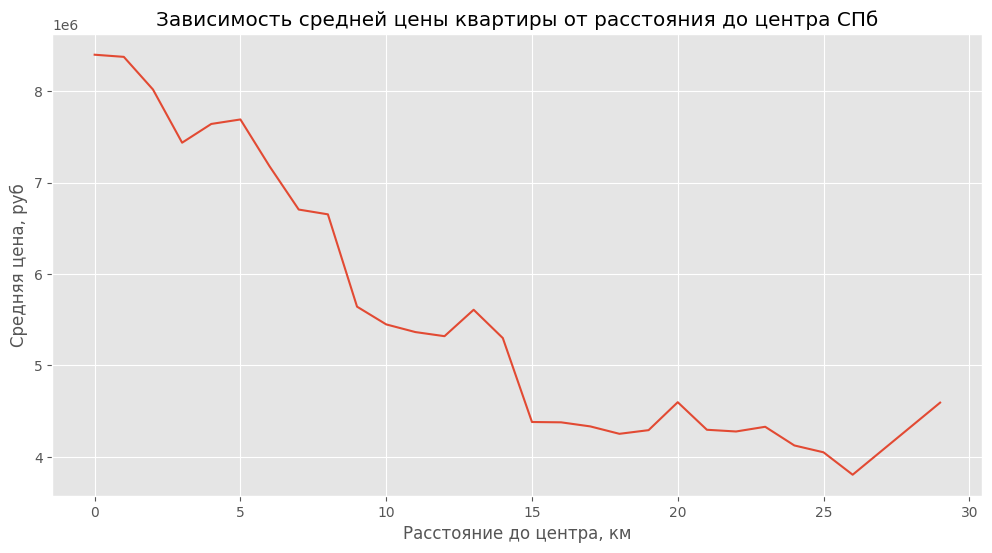

In [ ]:
# Посчитаем среднюю цену для каждого километра
mean_price_by_distance = spb_df.groupby('city_center_distance_km')['last_price'].mean()

# Построим график зависимости цены от расстояния до центра
plt.figure(figsize=(12, 6))
mean_price_by_distance.plot()
plt.title('Зависимость средней цены квартиры от расстояния до центра СПб')
plt.xlabel('Расстояние до центра, км')
plt.ylabel('Средняя цена, руб')
plt.grid(True)
plt.show()

In [ ]:
# Определим границу центральной зоны (где график сильно меняется)
# Для этого найдем точку наибольшего изменения производной (наклона)
price_diff = mean_price_by_distance.diff().abs()
central_zone_boundary = price_diff.idxmax()
print(f"\nГраница центральной зоны: примерно {central_zone_boundary} км от центра")


Граница центральной зоны: примерно 9 км от центра



Основные параметры квартир в центре СПб:
Количество квартир: 3139
Средняя цена: 7085783.35 руб
Средняя площадь: 63.96 кв.м
Среднее число комнат: 2.26
Средняя высота потолков: 2.73 м

Корреляция параметров с ценой в центре СПб:
last_price                 1.000000
total_area                 0.722107
rooms                      0.500498
ceiling_height             0.186534
floor                      0.053742
city_center_distance_km   -0.307212
Name: last_price, dtype: float64

Сравнение с общими параметрами по всему СПб:
Средняя цена по городу: 5577861.87 руб
Средняя площадь по городу: 53.75 кв.м
Среднее число комнат по городу: 1.95
Средняя высота потолков по городу: 2.65 м


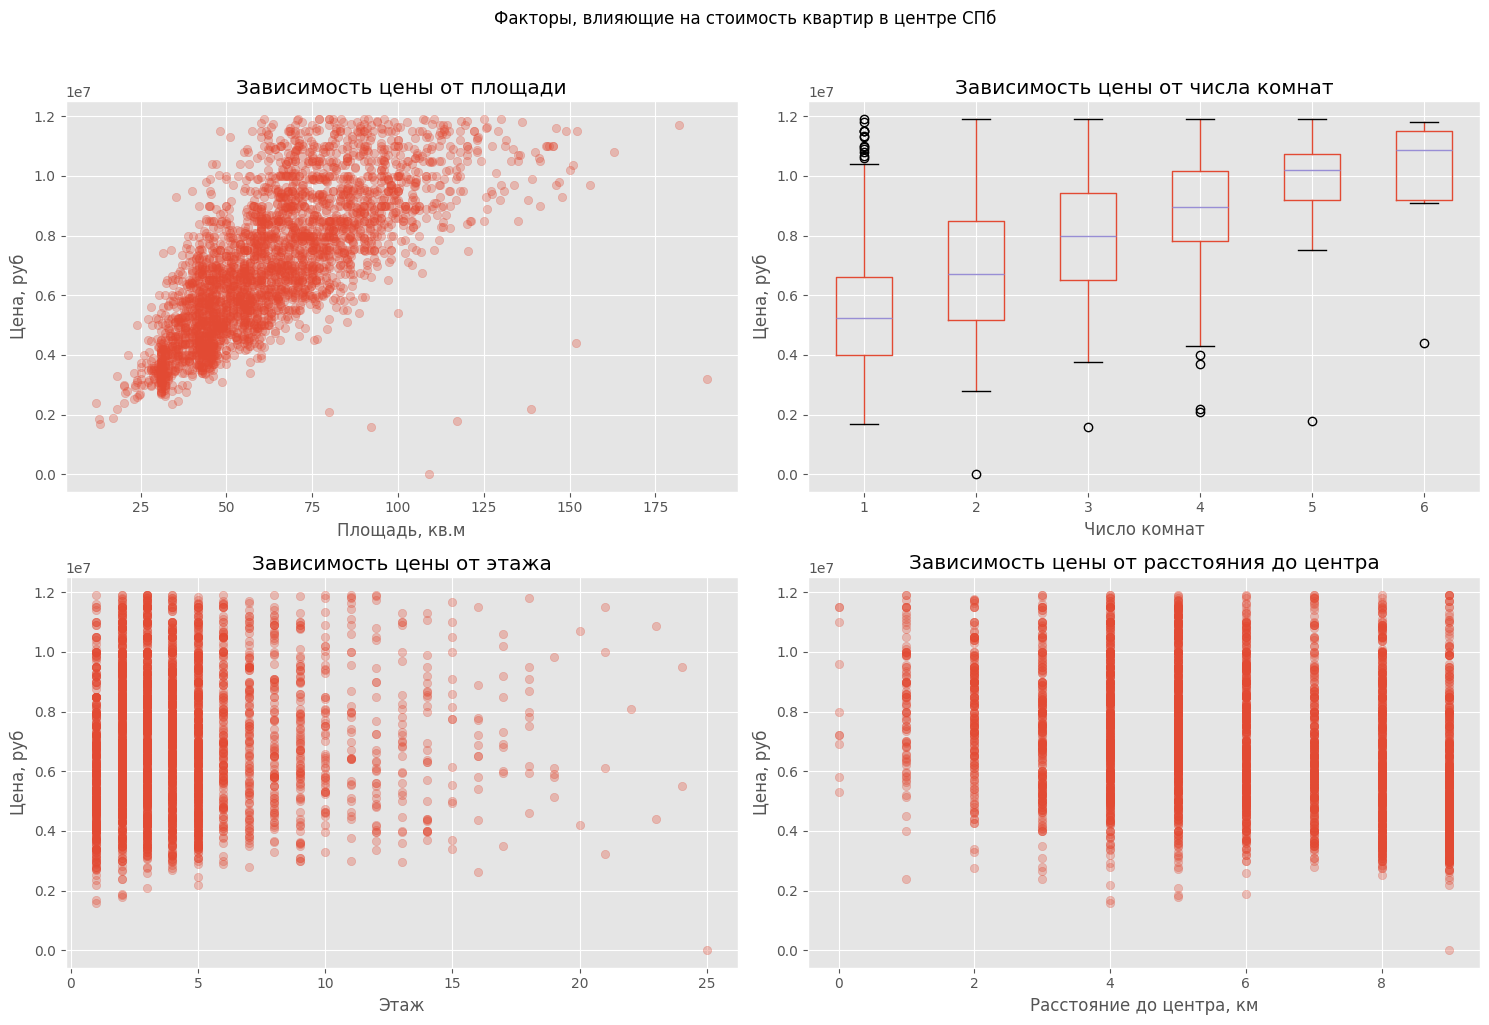


Выводы:
1. В центре Санкт-Петербурга квартиры значительно дороже, чем в среднем по городу.
2. Основные факторы, влияющие на стоимость в центре: площадь и число комнат.
3. Высота потолков в центре в среднем выше, чем по городу.
4. Зависимость цены от расстояния до центра наиболее заметна в пределах 5-7 км.
5. В центре преобладают квартиры с большей площадью и числом комнат по сравнению с общими показателями по городу.


In [ ]:
# Задача 3: Анализ квартир в центре Санкт-Петербурга
# Выделим квартиры в центральной зоне
central_df = spb_df[spb_df['city_center_distance_km'] <= central_zone_boundary].copy()

# Проанализируем основные параметры
print("\nОсновные параметры квартир в центре СПб:")
print(f"Количество квартир: {len(central_df)}")
print(f"Средняя цена: {central_df['last_price'].mean():.2f} руб")
print(f"Средняя площадь: {central_df['total_area'].mean():.2f} кв.м")
print(f"Среднее число комнат: {central_df['rooms'].mean():.2f}")
print(f"Средняя высота потолков: {central_df['ceiling_height'].mean():.2f} м")

# Анализ факторов, влияющих на стоимость
print("\nКорреляция параметров с ценой в центре СПб:")
correlation = central_df[['last_price', 'rooms', 'total_area', 'floor', 'city_center_distance_km', 'ceiling_height']].corr()
print(correlation['last_price'].sort_values(ascending=False))

# Сравним с общими выводами по всему городу
print("\nСравнение с общими параметрами по всему СПб:")
print(f"Средняя цена по городу: {spb_df['last_price'].mean():.2f} руб")
print(f"Средняя площадь по городу: {spb_df['total_area'].mean():.2f} кв.м")
print(f"Среднее число комнат по городу: {spb_df['rooms'].mean():.2f}")
print(f"Средняя высота потолков по городу: {spb_df['ceiling_height'].mean():.2f} м")

# Визуализация зависимости цены от различных факторов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Цена от площади
axes[0, 0].scatter(central_df['total_area'], central_df['last_price'], alpha=0.3)
axes[0, 0].set_title('Зависимость цены от площади')
axes[0, 0].set_xlabel('Площадь, кв.м')
axes[0, 0].set_ylabel('Цена, руб')

# Цена от числа комнат
central_df.boxplot(column='last_price', by='rooms', ax=axes[0, 1])
axes[0, 1].set_title('Зависимость цены от числа комнат')
axes[0, 1].set_xlabel('Число комнат')
axes[0, 1].set_ylabel('Цена, руб')

# Цена от этажа
axes[1, 0].scatter(central_df['floor'], central_df['last_price'], alpha=0.3)
axes[1, 0].set_title('Зависимость цены от этажа')
axes[1, 0].set_xlabel('Этаж')
axes[1, 0].set_ylabel('Цена, руб')

# Цена от расстояния до центра
axes[1, 1].scatter(central_df['city_center_distance_km'], central_df['last_price'], alpha=0.3)
axes[1, 1].set_title('Зависимость цены от расстояния до центра')
axes[1, 1].set_xlabel('Расстояние до центра, км')
axes[1, 1].set_ylabel('Цена, руб')

plt.tight_layout()
plt.suptitle('Факторы, влияющие на стоимость квартир в центре СПб', y=1.02)
plt.show()

# Выводы
print("\nВыводы:")
print("1. В центре Санкт-Петербурга квартиры значительно дороже, чем в среднем по городу.")
print("2. Основные факторы, влияющие на стоимость в центре: площадь и число комнат.")
print("3. Высота потолков в центре в среднем выше, чем по городу.")
print("4. Зависимость цены от расстояния до центра наиболее заметна в пределах 5-7 км.")
print("5. В центре преобладают квартиры с большей площадью и числом комнат по сравнению с общими показателями по городу.")

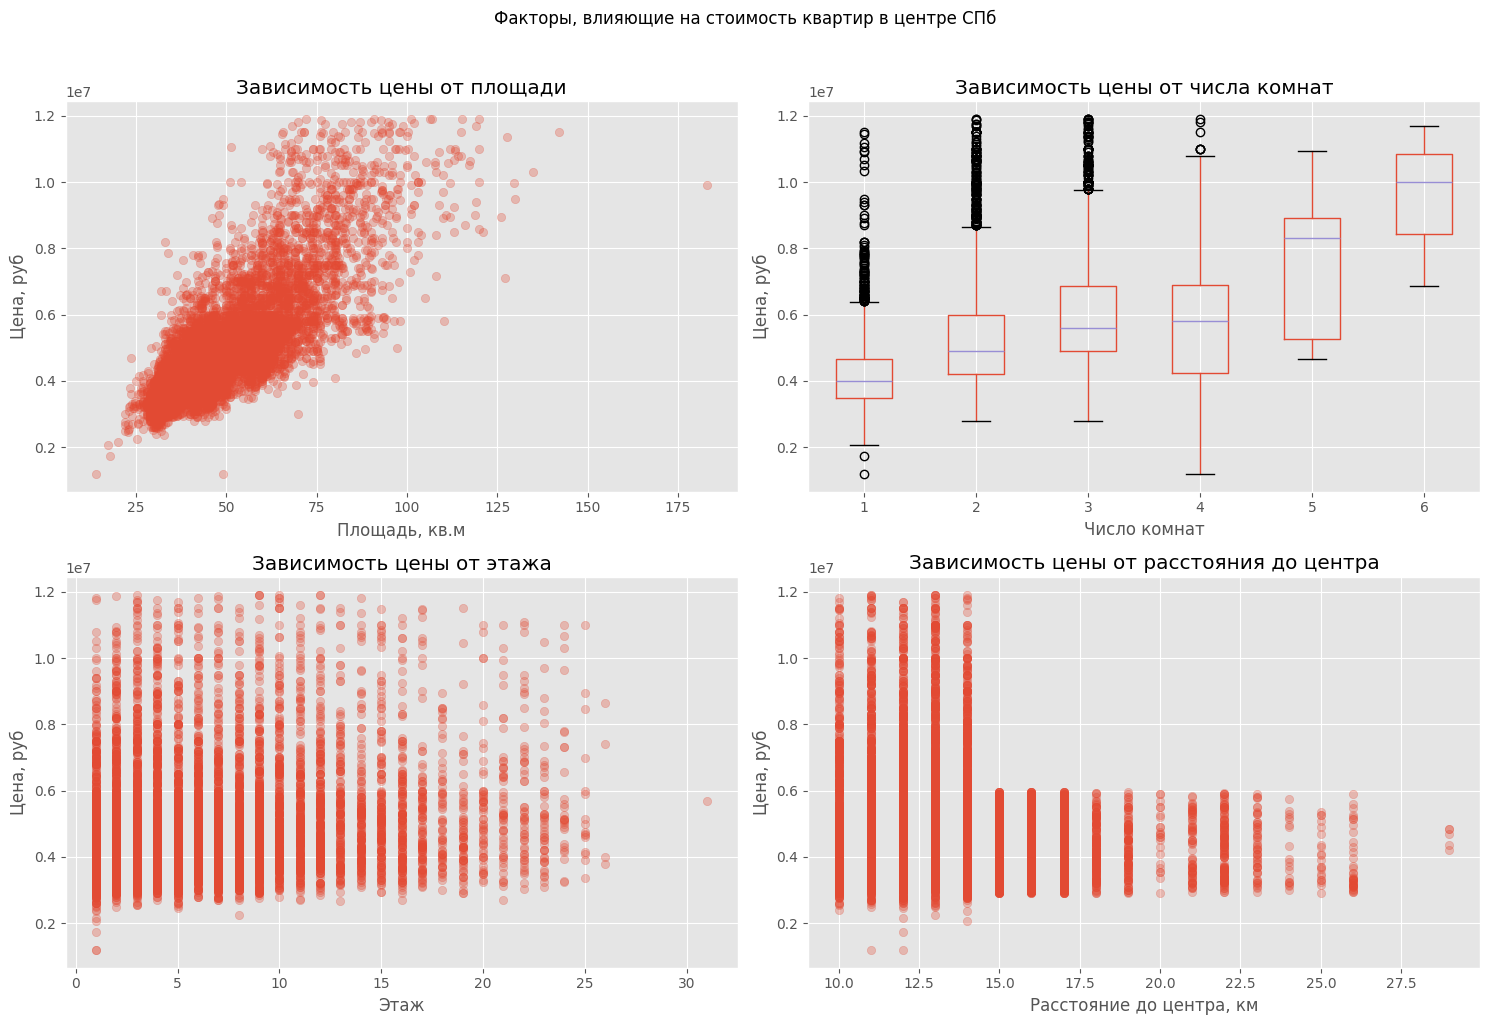


Выводы:
1. В центре Санкт-Петербурга квартиры значительно дороже, чем в среднем по городу.
2. Основные факторы, влияющие на стоимость в центре: площадь и число комнат.
3. Высота потолков в центре в среднем выше, чем по городу.
4. Зависимость цены от расстояния до центра наиболее заметна в пределах 5-7 км.
5. В центре преобладают квартиры с большей площадью и числом комнат по сравнению с общими показателями по городу.


In [ ]:

noncentral_df = spb_df[spb_df['city_center_distance_km'] > central_zone_boundary].copy()

# Визуализация зависимости цены от различных факторов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Цена от площади
axes[0, 0].scatter(noncentral_df['total_area'], noncentral_df['last_price'], alpha=0.3)
axes[0, 0].set_title('Зависимость цены от площади')
axes[0, 0].set_xlabel('Площадь, кв.м')
axes[0, 0].set_ylabel('Цена, руб')

# Цена от числа комнат
noncentral_df.boxplot(column='last_price', by='rooms', ax=axes[0, 1])
axes[0, 1].set_title('Зависимость цены от числа комнат')
axes[0, 1].set_xlabel('Число комнат')
axes[0, 1].set_ylabel('Цена, руб')

# Цена от этажа
axes[1, 0].scatter(noncentral_df['floor'], noncentral_df['last_price'], alpha=0.3)
axes[1, 0].set_title('Зависимость цены от этажа')
axes[1, 0].set_xlabel('Этаж')
axes[1, 0].set_ylabel('Цена, руб')

# Цена от расстояния до центра
axes[1, 1].scatter(noncentral_df['city_center_distance_km'], noncentral_df['last_price'], alpha=0.3)
axes[1, 1].set_title('Зависимость цены от расстояния до центра')
axes[1, 1].set_xlabel('Расстояние до центра, км')
axes[1, 1].set_ylabel('Цена, руб')

plt.tight_layout()
plt.suptitle('Факторы, влияющие на стоимость квартир в центре СПб', y=1.02)
plt.show()

# Выводы
print("\nВыводы:")
print("1. В центре Санкт-Петербурга квартиры значительно дороже, чем в среднем по городу.")
print("2. Основные факторы, влияющие на стоимость в центре: площадь и число комнат.")
print("3. Высота потолков в центре в среднем выше, чем по городу.")
print("4. Зависимость цены от расстояния до центра наиболее заметна в пределах 5-7 км.")
print("5. В центре преобладают квартиры с большей площадью и числом комнат по сравнению с общими показателями по городу.")

Так как зависимость цены от различных параметров отличается незначительно, следовательно можно строить регрессию, основываясь на квартирах всего города

In [ ]:
column_names = spb_df.columns
print(column_names)

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition', 'living_area_studio',
       'ceiling_height_apartment', 'ceiling_height_regular',
       'ceiling_height_studio', 'living_area_regular', 'living_area_apartment',
       'kitchen_area_regular', 'kitchen_area_apartment', 'kitchen_area_studio',
       'balcony_regular', 'balcony_apartment', 'balcony_studio',
       'price_per_sqm', 'day_of_week', 'day_of_week_name', 'month',
       'month_name', 'year', 'floor_type', 'living_to_total_ratio',
       'kitchen_to_total_ratio', 'city_center_distance_km'],
      dtype='object')


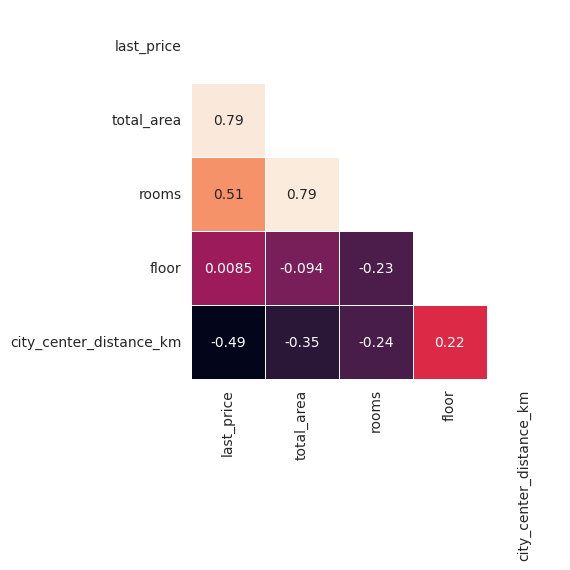

In [ ]:
corr = spb_df [[ 'last_price', 'total_area', 'rooms', 'floor', 'city_center_distance_km']].corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
  ax = sns.heatmap(corr, mask=mask, square=True, cbar=False, annot=True, linewidths=.5)


Присутсвуют высокие коэффициенты корреляции между переменными, что может свидетельствовать о мультиколлинеарности.

Проверим гипотезы о статистической значимости парных коэффициентов корреляции

In [ ]:
from scipy.stats import pearsonr
r, p = pearsonr(spb_df.last_price, spb_df.total_area)
print('Выборочный коэффициент корреляции между переменными у и x1 равен', round(r,3))
print('Фактическая вероятность равна', round(p,3))
if p < 0.05:
  print('Нулевая гипотеза отвергается на уровне значимости 0.05. Коэффициент статистически значим')
else:
  print('Нет оснований отвергнуть нулевую гипотезу на уровне значимости 0.05. Коэффициент статистически не значим')

Выборочный коэффициент корреляции между переменными у и x1 равен 0.786
Фактическая вероятность равна 0.0
Нулевая гипотеза отвергается на уровне значимости 0.05. Коэффициент статистически значим


In [ ]:
from scipy.stats import pearsonr
r, p = pearsonr(spb_df.last_price, spb_df.rooms)
print('Выборочный коэффициент корреляции между переменными у и x1 равен', round(r,3))
print('Фактическая вероятность равна', round(p,3))
if p < 0.05:
  print('Нулевая гипотеза отвергается на уровне значимости 0.05. Коэффициент статистически значим')
else:
  print('Нет оснований отвергнуть нулевую гипотезу на уровне значимости 0.05. Коэффициент статистически не значим')

Выборочный коэффициент корреляции между переменными у и x1 равен 0.507
Фактическая вероятность равна 0.0
Нулевая гипотеза отвергается на уровне значимости 0.05. Коэффициент статистически значим


In [ ]:
from scipy.stats import pearsonr
r, p = pearsonr(spb_df.last_price, spb_df.floor)
print('Выборочный коэффициент корреляции между переменными у и x1 равен', round(r,3))
print('Фактическая вероятность равна', round(p,3))
if p < 0.05:
  print('Нулевая гипотеза отвергается на уровне значимости 0.05. Коэффициент статистически значим')
else:
  print('Нет оснований отвергнуть нулевую гипотезу на уровне значимости 0.05. Коэффициент статистически не значим')

Выборочный коэффициент корреляции между переменными у и x1 равен 0.009
Фактическая вероятность равна 0.355
Нет оснований отвергнуть нулевую гипотезу на уровне значимости 0.05. Коэффициент статистически не значим


In [ ]:
from scipy.stats import pearsonr
r, p = pearsonr(spb_df.last_price, spb_df.city_center_distance_km)
print('Выборочный коэффициент корреляции между переменными у и x1 равен', round(r,3))
print('Фактическая вероятность равна', round(p,3))
if p < 0.05:
  print('Нулевая гипотеза отвергается на уровне значимости 0.05. Коэффициент статистически значим')
else:
  print('Нет оснований отвергнуть нулевую гипотезу на уровне значимости 0.05. Коэффициент статистически не значим')

Выборочный коэффициент корреляции между переменными у и x1 равен -0.491
Фактическая вероятность равна 0.0
Нулевая гипотеза отвергается на уровне значимости 0.05. Коэффициент статистически значим


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

Создадим датасет для построения регрессии

In [ ]:
reg_df = spb_df[['last_price', 'total_area', 'rooms', 'floor', 'city_center_distance_km']]
reg_df = reg_df.astype(np.float64)

In [ ]:
y_1 = reg_df['total_area']

In [ ]:
y_1.head()

,total_area
2,56.0
4,100.0
7,71.6
9,61.0
10,39.6


In [ ]:
X_1 = reg_df.drop(['last_price', 'total_area'], axis=1)

In [ ]:
X_1 = sm.add_constant(X_1)

In [ ]:
X_1.head()

,const,rooms,floor,city_center_distance_km
2,1.0,2.0,4.0,14.0
4,1.0,2.0,13.0,8.0
7,1.0,2.0,22.0,12.0
9,1.0,3.0,7.0,15.0
10,1.0,1.0,3.0,14.0


Обучим модель

In [ ]:
model_1 = sm.OLS (y_1, X_1).fit()
print (model_1.summary())

                            OLS Regression Results                            
Dep. Variable:             total_area   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     8017.
Date:                Thu, 26 Jun 2025   Prob (F-statistic):               0.00
Time:                        13:29:36   Log-Likelihood:                -44997.
No. Observations:               11806   AIC:                         9.000e+04
Df Residuals:                   11802   BIC:                         9.003e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
y_2 = reg_df['rooms']

In [ ]:
y_2.head()

,rooms
2,2.0
4,2.0
7,2.0
9,3.0
10,1.0


In [ ]:
X_2 = reg_df.drop(['last_price', 'rooms'], axis=1)

In [ ]:
X_2 = sm.add_constant(X_2)

In [ ]:
X_2.head()

,const,total_area,floor,city_center_distance_km
2,1.0,56.0,4.0,14.0
4,1.0,100.0,13.0,8.0
7,1.0,71.6,22.0,12.0
9,1.0,61.0,7.0,15.0
10,1.0,39.6,3.0,14.0


Обучим модель

In [ ]:
model_2 = sm.OLS (y_2, X_2).fit()
print (model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  rooms   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     7655.
Date:                Thu, 26 Jun 2025   Prob (F-statistic):               0.00
Time:                        13:29:36   Log-Likelihood:                -9334.4
No. Observations:               11806   AIC:                         1.868e+04
Df Residuals:                   11802   BIC:                         1.871e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
y_3 = reg_df['floor']

In [ ]:
y_3.head()

,floor
2,4.0
4,13.0
7,22.0
9,7.0
10,3.0


In [ ]:
X_3 = reg_df.drop(['last_price', 'floor'], axis=1)

In [ ]:
X_3 = sm.add_constant(X_3)

In [ ]:
X_3.head()

,const,total_area,rooms,city_center_distance_km
2,1.0,56.0,2.0,14.0
4,1.0,100.0,2.0,8.0
7,1.0,71.6,2.0,12.0
9,1.0,61.0,3.0,15.0
10,1.0,39.6,1.0,14.0


Обучим модель

In [ ]:
model_3 = sm.OLS (y_3, X_3).fit()
print (model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  floor   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     547.0
Date:                Thu, 26 Jun 2025   Prob (F-statistic):               0.00
Time:                        13:29:36   Log-Likelihood:                -34414.
No. Observations:               11806   AIC:                         6.884e+04
Df Residuals:                   11802   BIC:                         6.886e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
y_4 = reg_df['city_center_distance_km']

In [ ]:
y_4.head()

,city_center_distance_km
2,14.0
4,8.0
7,12.0
9,15.0
10,14.0


In [ ]:
X_4 = reg_df.drop(['last_price', 'city_center_distance_km'], axis=1)

In [ ]:
X_4 = sm.add_constant(X_4)

In [ ]:
X_4.head()

,const,total_area,rooms,floor
2,1.0,56.0,2.0,4.0
4,1.0,100.0,2.0,13.0
7,1.0,71.6,2.0,22.0
9,1.0,61.0,3.0,7.0
10,1.0,39.6,1.0,3.0


Обучим модель

In [ ]:
model_4 = sm.OLS (y_4, X_4).fit()
print (model_4.summary())

                               OLS Regression Results                              
Dep. Variable:     city_center_distance_km   R-squared:                       0.165
Model:                                 OLS   Adj. R-squared:                  0.165
Method:                      Least Squares   F-statistic:                     779.1
Date:                     Thu, 26 Jun 2025   Prob (F-statistic):               0.00
Time:                             13:29:36   Log-Likelihood:                -33409.
No. Observations:                    11806   AIC:                         6.683e+04
Df Residuals:                        11802   BIC:                         6.686e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

Наибольший коэффициент множественной детерминации наблюдается для переменных 'total_area' и 'rooms'. Так как переменная 'total_area' несет в себе больше информации, исключаем переменную 'rooms'

In [ ]:
reg_df_new = reg_df.drop(['rooms'], axis=1)
y=reg_df_new['last_price']
X=reg_df_new.drop(['last_price'], axis=1)
X =sm.add_constant(X)
model_regression = sm.OLS (y, X).fit()
print(model_regression.summary())

                            OLS Regression Results                            
Dep. Variable:             last_price   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.690
Method:                 Least Squares   F-statistic:                     8741.
Date:                Thu, 26 Jun 2025   Prob (F-statistic):               0.00
Time:                        13:29:36   Log-Likelihood:            -1.8150e+05
No. Observations:               11806   AIC:                         3.630e+05
Df Residuals:                   11802   BIC:                         3.630e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    2

Построим графики частичной регрессии

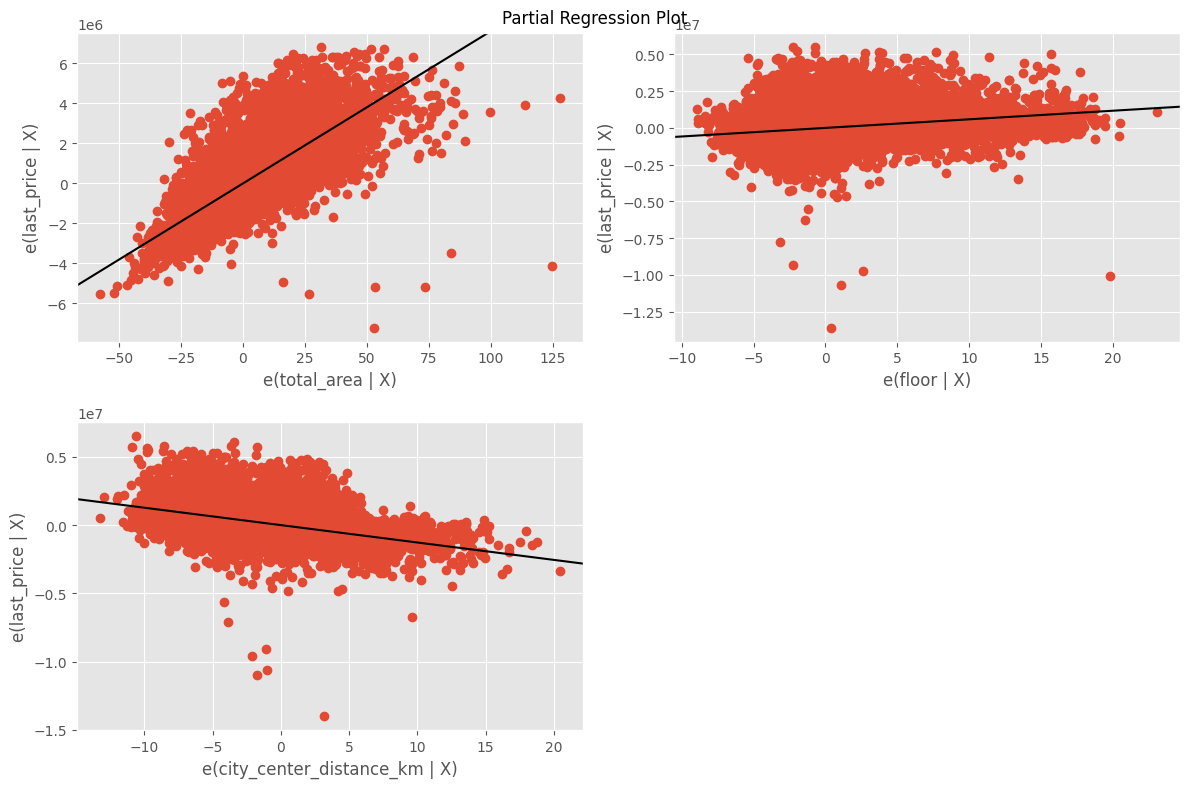

In [ ]:
fig = plt.figure(figsize=(12,8))
fig = sm.graphics.plot_partregress_grid (model_regression, exog_idx = ['total_area', 'floor','city_center_distance_km'], fig=fig)

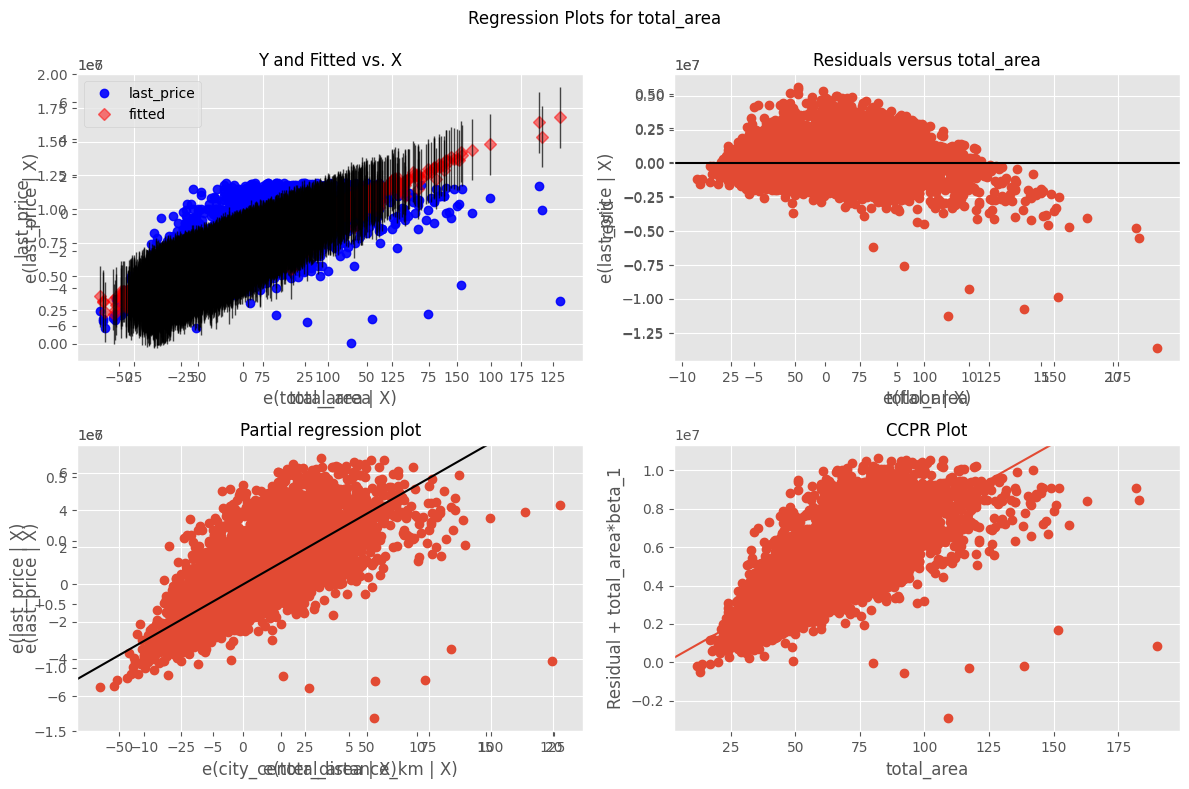

In [ ]:
fig_1 = sm.graphics.plot_regress_exog(model_regression, 'total_area', fig=fig)
fig_1

Дисперсия распределена неравномерно. Есть гетероскедастичность.

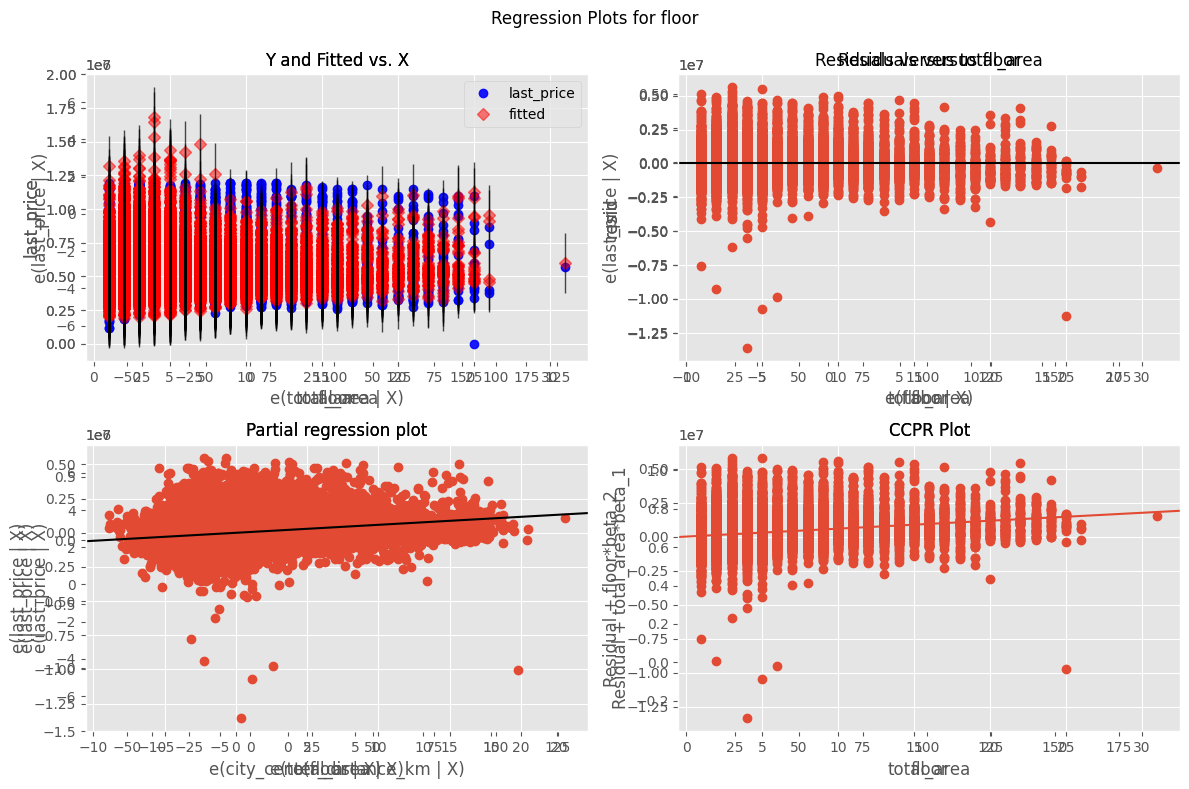

In [ ]:
fig_2 = sm.graphics.plot_regress_exog(model_regression, 'floor', fig=fig)
fig_2

Дисперсия распределена неравномерно. Есть гетероскедастичность.

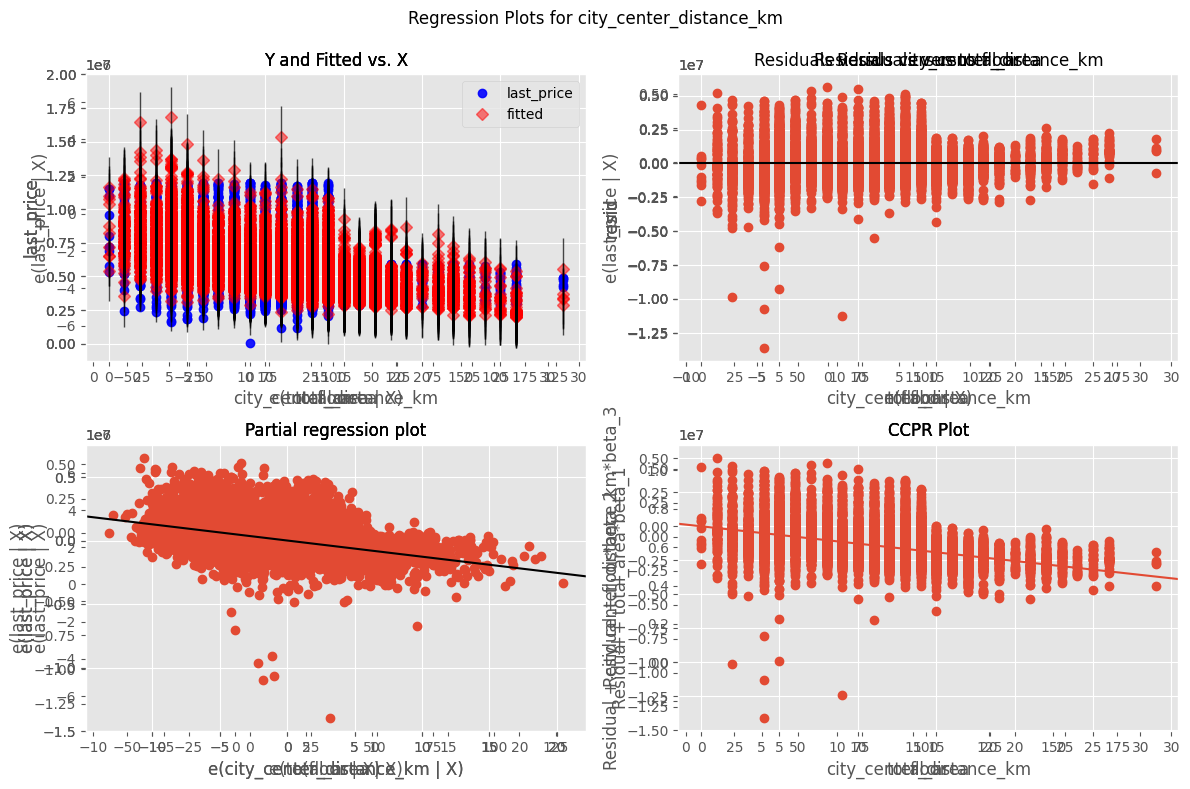

In [ ]:
fig_3 = sm.graphics.plot_regress_exog(model_regression, 'city_center_distance_km', fig=fig)
fig_3

Дисперсия распределена неравномерно. Есть гетероскедастичность.

Сформируем столбцы предсказанных значений, остатков, квадратов остатков

In [ ]:
reg_df_new['predict'] = model_regression.predict(X)
reg_df_new ['resid'] = model_regression.resid
reg_df_new ['resid_sqr'] = reg_df_new ['resid']*reg_df_new ['resid']
reg_df_new.head()

,last_price,total_area,floor,city_center_distance_km,predict,resid,resid_sqr
2,5196000.0,56.0,4.0,14.0,5.338304e+06,-1.423044e+05,2.025053e+10
4,10000000.0,100.0,13.0,8.0,9.975666e+06,2.433437e+04,5.921618e+08
7,7915000.0,71.6,22.0,12.0,7.831538e+06,8.346175e+04,6.965864e+09
9,5400000.0,61.0,7.0,15.0,5.766640e+06,-3.666396e+05,1.344246e+11
10,5050000.0,39.6,3.0,14.0,4.032194e+06,1.017806e+06,1.035929e+12


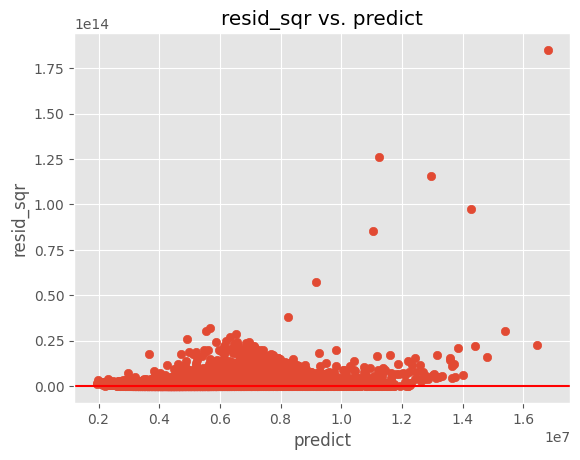

In [ ]:
plt.scatter(reg_df_new['predict'], reg_df_new ['resid_sqr'])
plt.xlabel('predict')
plt.ylabel('resid_sqr')
plt.axhline (y=0, color='r', linestyle='-')
plt.title('resid_sqr vs. predict')
plt.show()

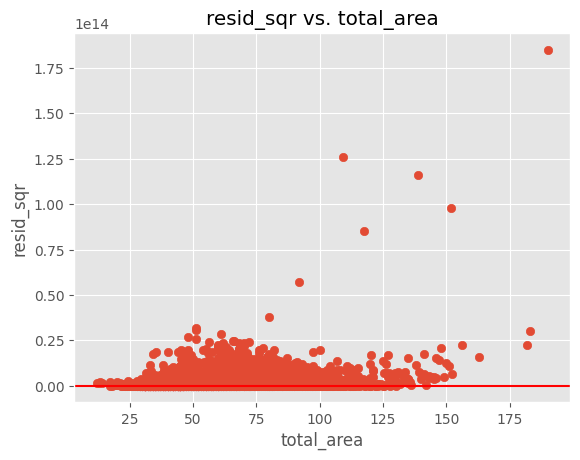

In [ ]:
plt.scatter(reg_df_new['total_area'], reg_df_new ['resid_sqr'])
plt.xlabel('total_area')
plt.ylabel('resid_sqr')
plt.axhline (y=0, color='r', linestyle='-')
plt.title('resid_sqr vs. total_area')
plt.show()

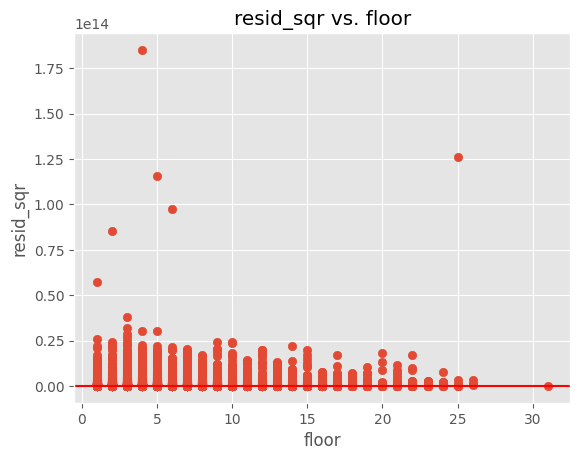

In [ ]:
plt.scatter(reg_df_new['floor'], reg_df_new ['resid_sqr'])
plt.xlabel('floor')
plt.ylabel('resid_sqr')
plt.axhline (y=0, color='r', linestyle='-')
plt.title('resid_sqr vs. floor')
plt.show()

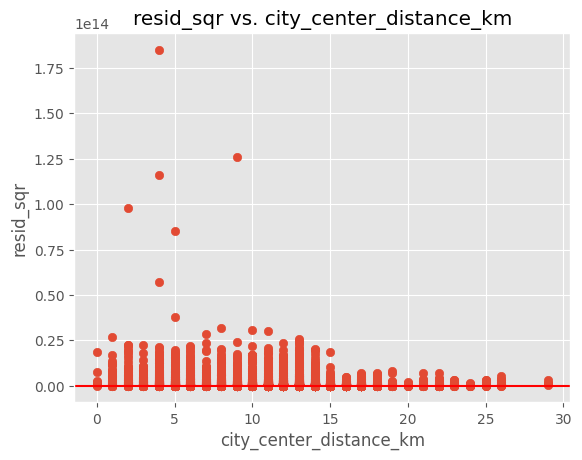

In [ ]:
plt.scatter(reg_df_new['city_center_distance_km'], reg_df_new ['resid_sqr'])
plt.xlabel('city_center_distance_km')
plt.ylabel('resid_sqr')
plt.axhline (y=0, color='r', linestyle='-')
plt.title('resid_sqr vs. city_center_distance_km')
plt.show()

Во всех случаях можем наблюдать неравномерность дисперсий ошибок (гетероскедастичность)

Тест Голфелда-Квандта для проверки гетероскедастичности

Для total_area

In [ ]:
from statsmodels.stats.diagnostic import het_goldfeldquandt
goldfeldquandt_test = het_goldfeldquandt(y, X, idx=1, drop=0.25, alternative ='increasing')
print(f"F statistic: {goldfeldquandt_test[0]}")
print(f"p-value: {goldfeldquandt_test[1]}")

F statistic: 4.005776722698225
p-value: 0.0


Гипотеза о наличии гетероскедастичности подтверждается

---



Для floor

In [ ]:
from statsmodels.stats.diagnostic import het_goldfeldquandt
goldfeldquandt_test = het_goldfeldquandt(y, X, idx=2, drop=0.25, alternative ='decreasing')
print(f"F statistic: {goldfeldquandt_test[0]}")
print(f"p-value: {goldfeldquandt_test[1]}")

F statistic: 0.9084862069972072
p-value: 0.0012315697835726914


Гипотеза о наличие гетероскедастичности отвергается

Для city_center_distance_km

In [ ]:
from statsmodels.stats.diagnostic import het_goldfeldquandt
goldfeldquandt_test = het_goldfeldquandt(y, X, idx=3, drop=0.25, alternative ='decreasing')
print(f"F statistic: {goldfeldquandt_test[0]}")
print(f"p-value: {goldfeldquandt_test[1]}")

F statistic: 0.17354378244104451
p-value: 0.0


Гипотеза о наличие гетероскедастичности подтверждается

Проведем тест Уайта для проверки гетероскедастичности

In [ ]:
from statsmodels.stats.diagnostic import het_white
white_test = het_white(model_regression.resid, model_regression.model.exog)

print(f"X statistic: {white_test[0]}")
print(f"p-value: {white_test[1]}")

X statistic: 1463.7944140467262
p-value: 1.26791953182766e-309


P<0.05 следовательно, гипотеза об отсутсвии гетероскедастичности отвергается

In [ ]:
from statsmodels.stats.stattools import durbin_watson
durbin_watson(model_regression.resid)

np.float64(2.0421581383466183)

Для больших выборок при количестве переменных, равному 3 значения dl и du приблизительно равны ~1.63	~1.72 при a = 0.05 Поэтому, т.к полученное значение находится между dl и du, можно утверждать, что автокорреляция отсутствует

Построим уравнение множественнорй линейной регрессии

In [ ]:
from sklearn.linear_model import LinearRegression
model_regression_2 = LinearRegression().fit(X, y)

In [ ]:
model_regression_2.intercept_

np.float64(2627020.163736148)

In [ ]:
model_regression_2.coef_

array([      0.        ,   76078.10633103,   58429.37133931,
       -127343.37479006])

In [ ]:
reg_df_new['predict_2'] = model_regression_2.predict(X)
reg_df_new

,last_price,total_area,floor,city_center_distance_km,predict,resid,resid_sqr,predict_2
2,5196000.0,56.00,4.0,14.0,5.338304e+06,-1.423044e+05,2.025053e+10,5.338304e+06
4,10000000.0,100.00,13.0,8.0,9.975666e+06,2.433437e+04,5.921618e+08,9.975666e+06
7,7915000.0,71.60,22.0,12.0,7.831538e+06,8.346175e+04,6.965864e+09,7.831538e+06
9,5400000.0,61.00,7.0,15.0,5.766640e+06,-3.666396e+05,1.344246e+11,5.766640e+06
10,5050000.0,39.60,3.0,14.0,4.032194e+06,1.017806e+06,1.035929e+12,4.032194e+06
...,...,...,...,...,...,...,...,...
23689,3550000.0,35.30,4.0,16.0,3.508801e+06,4.119919e+04,1.697374e+09,3.508801e+06
23690,5500000.0,52.00,2.0,6.0,5.935880e+06,-4.358802e+05,1.899915e+11,5.935880e+06
23691,9470000.0,72.90,7.0,4.0,8.072746e+06,1.397254e+06,1.952318e+12,8.072746e+06
23694,9700000.0,133.81,3.0,4.0,1.247295e+07,-2.772946e+06,7.689231e+12,1.247295e+07


Вычислим метрики регрессии

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
predict = model_regression_2.predict(X)
mse_1 = mean_squared_error(y, predict)
mae_1 = mean_absolute_error(y, predict)
r2_1 = r2_score (y, predict)
print('mse: %.2f, mae: %.2f, r2: %.2f' % (mse_1, mae_1, r2_1))

mse: 1321284749876.74, mae: 831395.06, r2: 0.69


Построем Lasso-регрессию

In [ ]:
from sklearn. linear_model import Lasso
X_all=reg_df.drop(['last_price'], axis=1)
X_all

,total_area,rooms,floor,city_center_distance_km
2,56.00,2.0,4.0,14.0
4,100.00,2.0,13.0,8.0
7,71.60,2.0,22.0,12.0
9,61.00,3.0,7.0,15.0
10,39.60,1.0,3.0,14.0
...,...,...,...,...
23689,35.30,1.0,4.0,16.0
23690,52.00,2.0,2.0,6.0
23691,72.90,2.0,7.0,4.0
23694,133.81,3.0,3.0,4.0


In [ ]:
model_regression_3 = LinearRegression().fit(X_all, y)

In [ ]:
model_regression_3.intercept_

np.float64(2570517.0982060824)

In [ ]:
model_regression_3.coef_

array([  98235.26829417, -574224.52095371,   39213.60350349,
       -118523.54559522])

In [ ]:
predict = model_regression_3.predict(X_all)
mse_2 = mean_squared_error(y, predict)
mae_2 = mean_absolute_error(y, predict)
r2_2 = r2_score (y, predict)
print('mse: %.2f, mae: %.2f, r2: %.2f' % (mse_2, mae_2, r2_2))

mse: 1227434341894.24, mae: 784611.89, r2: 0.71


Построем Ridge-регрессию

In [ ]:
from sklearn. linear_model import Ridge
model_regression_4 = Ridge().fit(X_all, y)

In [ ]:
model_regression_4.intercept_

np.float64(2570527.6361184753)

In [ ]:
model_regression_4.coef_

array([  98228.68746735, -574053.49031535,   39219.06800379,
       -118525.58708985])

In [ ]:
predict = model_regression_4.predict(X_all)
mse_3 = mean_squared_error(y, predict)
mae_3 = mean_absolute_error(y, predict)
r2_3 = r2_score (y, predict)
print('mse: %.2f, mae: %.2f, r2: %.2f' % (mse_3, mae_3, r2_3))

mse: 1227434350226.52, mae: 784612.69, r2: 0.71


Cравним метрики регрессий

In [ ]:
print('mse: %.2f, mae: %.2f, r2: %.2f' % (mse_1, mae_1, r2_1))
print('mse: %.2f, mae: %.2f, r2: %.2f' % (mse_2, mae_2, r2_2))
print('mse: %.2f, mae: %.2f, r2: %.2f' % (mse_3, mae_3, r2_3))

mse: 1321284749876.74, mae: 831395.06, r2: 0.69
mse: 1227434341894.24, mae: 784611.89, r2: 0.71
mse: 1227434350226.52, mae: 784612.69, r2: 0.71


В данном случае наилучшим образом показала себя Лассо-регрессия, так как она имеет наименьшие значения метрик ошибок mae и mse и наравне с Ridge-регрессией имеет наибольшее значение метрики качества модели r2

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19165 entries, 1 to 23698
Data columns (total 43 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   total_images              19165 non-null  int64         
 1   last_price                19165 non-null  float64       
 2   total_area                19165 non-null  float64       
 3   first_day_exposition      19165 non-null  datetime64[ns]
 4   rooms                     19165 non-null  Int64         
 5   ceiling_height            19165 non-null  float64       
 6   floors_total              19165 non-null  Int64         
 7   living_area               19165 non-null  float64       
 8   floor                     19165 non-null  Int64         
 9   is_apartment              19165 non-null  bool          
 10  studio                    19165 non-null  bool          
 11  open_plan                 19165 non-null  bool          
 12  kitchen_area           

Фильтр данных по типу жилья, месту проживания и нахождении в пределах центра города

In [ ]:
def filter_data(df, chosen_is_apartment, chosen_studio, chosen_locality_name, chosen_cityCenters_nearest, central_zone_boundary):
    # Фильтрация по is_apartment
    if chosen_is_apartment:
        df = df[df['is_apartment'] == True]
    else:
        df = df[df['is_apartment'] == False]

    # Фильтрация по studio
    if chosen_studio:
        df = df[df['studio'] == True]
    else:
        df = df[df['studio'] == False]

    # Фильтрация по locality_name
    if chosen_locality_name:
        df = df[df['locality_name'] == chosen_locality_name]

    # Фильтрация по cityCenters_nearest
    if chosen_cityCenters_nearest <= central_zone_boundary:
        df = df[df['cityCenters_nearest'] <= central_zone_boundary * 1000]
    else:
        df = df[df['cityCenters_nearest'] > central_zone_boundary * 1000]

    return df

In [ ]:
from sklearn.model_selection import train_test_split

def train_regression(df):
    # Выбор признаков и целевой переменной
    features = ['total_area', 'rooms', 'ceiling_height', 'floors_total', 'living_area',
                'floor', 'open_plan', 'kitchen_area', 'balcony', 'airports_nearest',
                'cityCenters_nearest']
    X = df[features]
    y = df['last_price']

    # Разделение данных на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Обучение модели Lasso
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Предсказание и оценка модели
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')
    print('Коэффициенты модели:', model.coef_)

    # Визуализация
    plt.figure(figsize=(15, 6))

    # График фактических vs предсказанных значений
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
    plt.xlabel('Фактические значения')
    plt.ylabel('Предсказанные значения')
    plt.title('Фактические vs Предсказанные значения')

    # График остатков
    plt.subplot(1, 2, 2)
    residuals = y_test - y_pred
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.title('Диаграмма остатков')

    plt.tight_layout()
    plt.show()

    return model

665
MSE: 484101749872.18, MAE: 520724.42, R2: 0.61
Коэффициенты модели: [ 4.01193589e+04 -2.43144615e+05  1.48854251e+06  2.33318600e+04
  4.87733906e+04  2.77363024e+04 -3.44350928e+05  1.15719347e+05
  3.76871803e+04  3.55621471e+00 -1.02260988e+02]


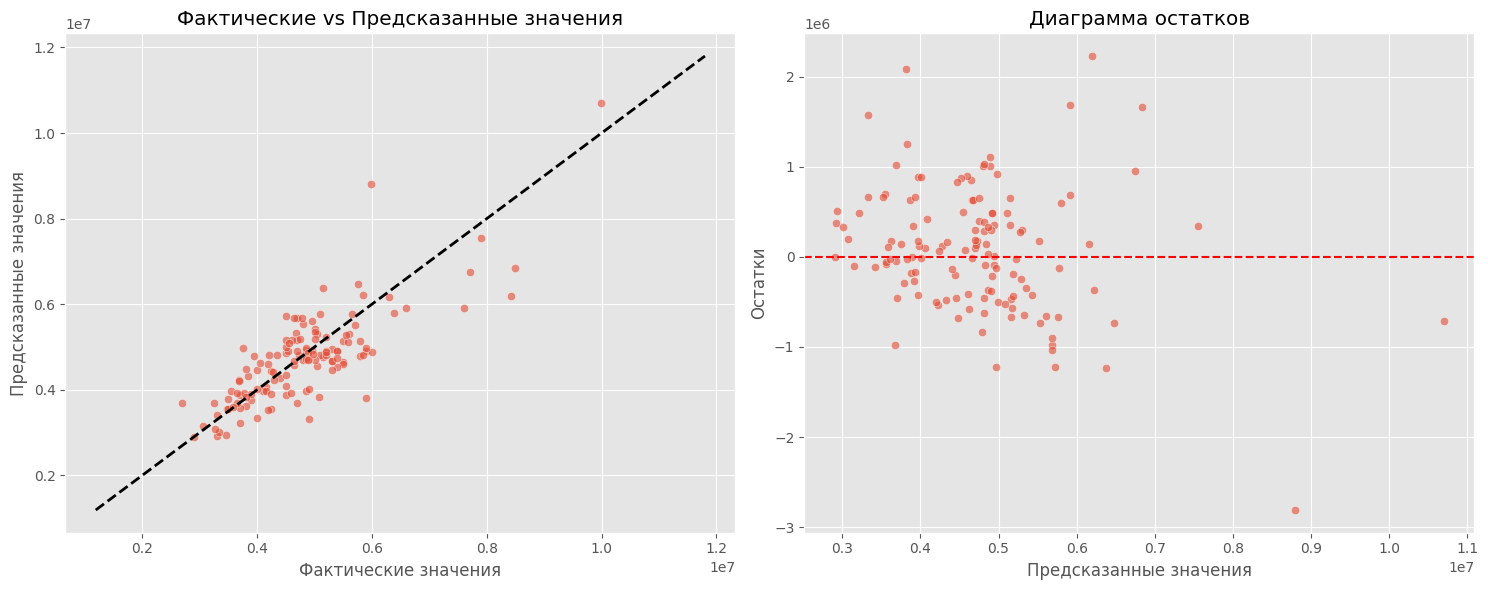

In [ ]:
# Параметры для фильтрации
chosen_is_apartment = False
chosen_studio = True
chosen_locality_name = 'Санкт-Петербург'
chosen_cityCenters_nearest = 15000  # Пример значения

# Фильтрация данных
filtered_df = filter_data(df, chosen_is_apartment, chosen_studio, chosen_locality_name,
                          chosen_cityCenters_nearest, central_zone_boundary)

print(len(filtered_df))
# Обучение модели
model = train_regression(filtered_df)

7994
MSE: 626202324462.67, MAE: 574929.18, R2: 0.75
Коэффициенты модели: [ 9.74990058e+04 -4.05449330e+05  6.34476220e+05  2.16136787e+04
 -4.09387392e+03  7.29623979e+03  7.15183667e+05  3.64763665e+04
  1.43015302e+05  1.52371093e+00 -9.91628229e+01]


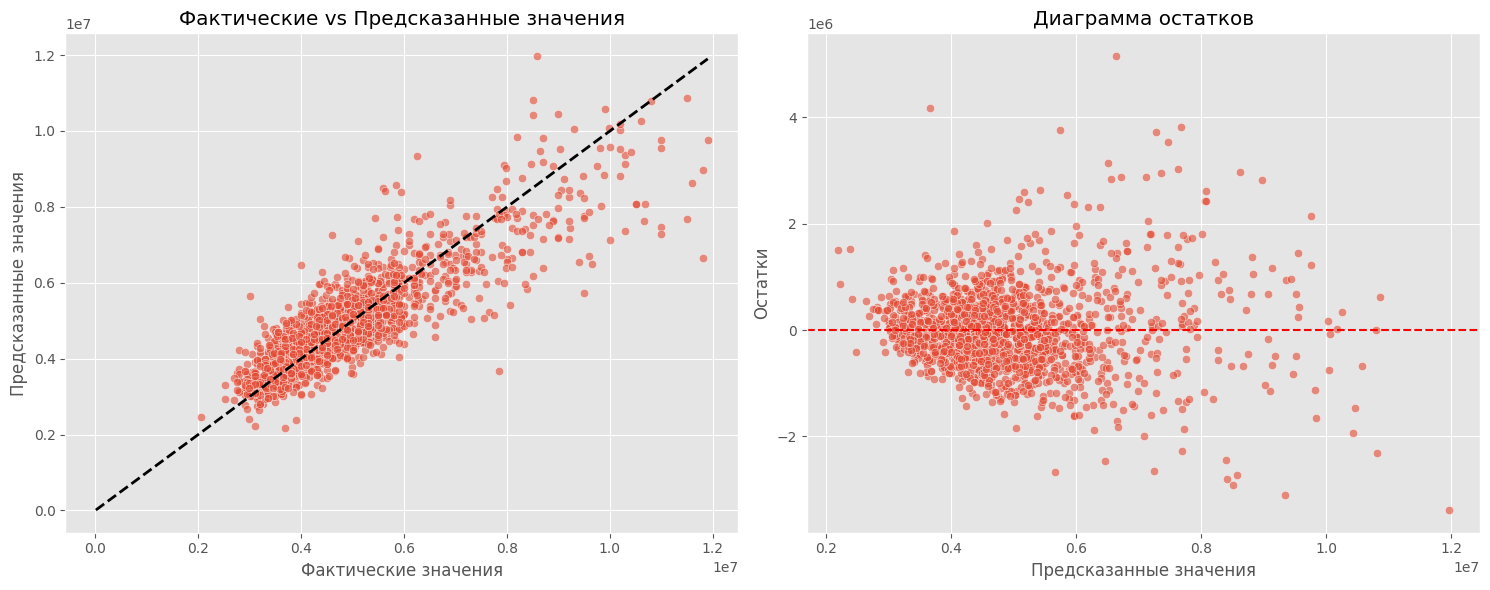

Предсказанная цена: [5647531.1377585]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Параметры для фильтрации
chosen_is_apartment = False
chosen_studio = False
chosen_locality_name = 'Санкт-Петербург'
chosen_cityCenters_nearest = 9500  # Пример значения

# Параметры для модели
model_data = [[54, 2, 2.6, 12, 35, 2, False, 8.3, 1, 26000, 9500]]

# Фильтрация данных
filtered_df = filter_data(df, chosen_is_apartment, chosen_studio, chosen_locality_name,
                          chosen_cityCenters_nearest, central_zone_boundary)

print(len(filtered_df))
model = train_regression(filtered_df)
predicted_price = model.predict(model_data)
print("Предсказанная цена:", predicted_price)